# Notebook 02 — Preparación, feature engineering y modelización

Cubre los apartados 5 (preparación de datos y feature engineering) y 6
(modelización) de la memoria.

## 0. Entorno y datos

El notebook parte del conjunto generado en el notebook 01: 31.418 viviendas de
Madrid correspondientes al cuarto trimestre de 2018, con la variable objetivo,
las variables explicativas disponibles en origen, las cuatro variables
geoespaciales construidas, los identificadores de zona y la geometría en
EPSG:4326.

El patrón de trabajo distingue la lectura de la escritura. El conjunto
preparado se copia de Google Drive al disco local de la máquina virtual mediante
`shutil` y se lee desde allí, dado que Drive es un montaje de red cuyo
rendimiento resulta inadecuado para lecturas repetidas. Las salidas —modelos,
artefactos y figuras— se escriben en cambio directamente sobre Drive: el
directorio de trabajo apunta a la carpeta del proyecto, de modo que las rutas
relativas se resuelven allí y los resultados persisten sin paso intermedio. Son
escrituras de un solo uso por ejecución, para las que el coste del montaje de
red resulta irrelevante.

La semilla `SEED` se declara una sola vez y se propaga a la partición, a los
esquemas de validación cruzada, a la búsqueda de hiperparámetros y a los
algoritmos que incorporan aleatoriedad. Constituye la condición de
reproducibilidad de todos los resultados del notebook.

In [1]:
# ----- Entorno -----
import os, shutil, warnings, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

drive.mount("/content/drive")

# Directorio de trabajo persistente. Ajustar la ruta a la carpeta del TFM.
RAIZ = Path("/content/drive/MyDrive/Master Data Science/TFM_AVM")
RAIZ.mkdir(parents=True, exist_ok=True)
os.chdir(RAIZ)

for d in ["modelos", "figuras"]:
    Path(d).mkdir(exist_ok=True)

print("Directorio de trabajo:", os.getcwd())

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("darkgrid")

SEED = 2018  # semilla única del notebook
N_HILOS = 4  # hilos de XGBoost, fijados para que el resultado sea reproducible

# ----- Rutas -----
# El directorio de trabajo apunta a Drive, de modo que las salidas escritas con
# ruta relativa —modelos y figuras— se persisten allí directamente. LOCAL aloja
# únicamente la copia de trabajo del conjunto preparado y los artefactos que
# después se copian a Drive de forma explícita.
BASE  = Path("/content/drive/MyDrive/Master Data Science/TFM_AVM")
LOCAL = Path("/content/tfm")

for sub in ["data/processed", "modelos"]:
    (LOCAL / sub).mkdir(parents=True, exist_ok=True)

# ----- Copia del conjunto preparado a disco local -----
FICHERO = "data/processed/madrid_201812_preparado.parquet"
shutil.copy(BASE / FICHERO, LOCAL / FICHERO)

# ----- Carga -----
gdf = gpd.read_parquet(LOCAL / FICHERO)

print(f"{gdf.shape[0]:,} filas x {gdf.shape[1]} columnas | CRS {gdf.crs.to_string()}")
print(f"numpy {np.__version__} | pandas {pd.__version__} | geopandas {gpd.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio de trabajo: /content/drive/MyDrive/Master Data Science/TFM_AVM
31,418 filas x 40 columnas | CRS EPSG:4326
numpy 2.1.3 | pandas 2.2.3 | geopandas 1.1.4


## 1. Partición train/test (memoria 6.1)

La partición se realiza de forma aleatoria por filas, con una proporción del
80/20 y estratificación por decil de precio. El experimento recogido en el
notebook 01 acreditó que la partición aleatoria por filas subestima el error
mediano en 0,8 puntos porcentuales cuando el mismo inmueble figura en ambos
conjuntos bajo anuncios distintos; la deduplicación por identificador elimina
esa circunstancia y deja una fila por vivienda, por lo que el procedimiento
resulta admisible.

La estratificación por decil de precio garantiza que el conjunto de validación
reproduzca la distribución de la variable objetivo, con particular atención a la
cola superior. Dicha cola reúne pocas observaciones y ejerce una influencia
elevada sobre las métricas, de modo que un sorteo desfavorable produciría
diferencias de rendimiento atribuibles a la partición y no al modelo. La
verificación posterior contrasta ambos conjuntos sobre los estadísticos de
posición del precio y sobre el número de barrios representados.

Se descarta la partición espacial por bloques, que reservaría zonas completas
para validación. Dicho esquema mide la transferibilidad del modelo a territorios
no observados, cuestión ajena al caso de uso considerado: la valoración se
aplica sobre el mismo mercado sobre el que se calibra.

La partición se aplica sobre el conjunto completo y no sobre una matriz de
variables explicativas ya definida. El conjunto final de variables se establece
en el apartado siguiente, una vez decidido el tratamiento de las categóricas. La
geometría y los identificadores de zona se conservan en ambas particiones por
resultar necesarios en el análisis espacial de residuos y en el análisis de
equidad del notebook 03.

La variable objetivo se transforma logarítmicamente sobre el conjunto de
entrenamiento, formulación adoptada como punto de partida en el notebook 01 y
empleada en las comprobaciones de especificación de este apartado.

In [2]:
from sklearn.model_selection import train_test_split

# Estrato: decil de precio
estrato = pd.qcut(gdf["PRICE"], q=10, labels=False)

train, test = train_test_split(
    gdf,
    test_size=0.20,
    random_state=SEED,
    stratify=estrato,
)

# Variable objetivo transformada, sobre entrenamiento
y_log = np.log(train["PRICE"])

print(f"Entrenamiento: {len(train):,} viviendas ({len(train)/len(gdf):.0%})")
print(f"Validación:    {len(test):,} viviendas ({len(test)/len(gdf):.0%})")

# ----- Verificación de la partición -----
comparativa = pd.DataFrame({
    "Entrenamiento": train["PRICE"].describe(percentiles=[.25, .5, .75, .95, .99]),
    "Validación":    test["PRICE"].describe(percentiles=[.25, .5, .75, .95, .99]),
})
# Se excluye la fila `count`: su desviación no es tal, sino el reparto 80/20,
# cuyo tamaño ya se imprime más arriba.
comparativa = comparativa.drop(index="count")
comparativa["Desviación %"] = (
    100 * (comparativa["Validación"] / comparativa["Entrenamiento"] - 1)
)
display(comparativa.round(2))

# Cobertura espacial: barrios presentes en cada partición
print(f"\nBarrios en entrenamiento: {train['LOCATIONNAME'].nunique()}")
print(f"Barrios en validación:    {test['LOCATIONNAME'].nunique()}")

Entrenamiento: 25,134 viviendas (80%)
Validación:    6,284 viviendas (20%)


,Entrenamiento,Validación,Desviación %
mean,405873.80,407833.86,0.48
std,431998.45,435544.34,0.82
min,24000.00,24000.00,0.00
25%,163000.00,163000.00,0.00
50%,268000.00,268000.00,0.00
75%,475000.00,473000.00,-0.42
95%,1177350.00,1178850.00,0.13
99%,2227010.00,2253930.00,1.21
max,8133000.00,7124000.00,-12.41



Barrios en entrenamiento: 135
Barrios en validación:    134


Ambos conjuntos presentan distribuciones equivalentes de la variable objetivo a
lo largo de los estadísticos de posición, con desviaciones inferiores al 1,3%
hasta el percentil 99. La única divergencia apreciable corresponde al máximo,
8.133.000 € frente a 7.124.000 €, consecuencia inevitable de que un valor
extremo caiga en una de las dos particiones y no en la otra: por definición no
admite reparto.

La cobertura espacial no es completa. El conjunto de entrenamiento recoge los
135 barrios y el de validación 134, de modo que un barrio queda sin
observaciones sobre las que evaluar. La circunstancia es irrelevante para las
métricas agregadas pero condiciona los análisis por zona: el procedimiento de
referencia del bloque 5 la contempla y el análisis de equidad del notebook 03
opera sobre validación.

Fuera de ese punto, la partición no introduce diferencias que puedan confundirse
con diferencias de rendimiento del modelo.

## 2. Grupos de variables y tramificaciones (memoria 5.1)

Las variables explicativas se clasifican en cuatro grupos según el tratamiento
que reciben en el preprocesado. Las numéricas se incorporan en su escala
original. Las binarias, ya codificadas como indicadores, no requieren
transformación. Las tramificadas se discretizan mediante cortes fijos. Las
categóricas se someten a codificación disyuntiva con categoría de referencia.

Los tres indicadores de tipo de obra constituyen una partición completa: suman
la unidad en la totalidad de los registros, lo que introduce dependencia lineal
si se incorporan simultáneamente. Dado que dicha estructura equivale ya a una
codificación disyuntiva, basta con descartar uno de ellos como categoría de
referencia. El conjunto de variables explicativas queda así en 35.

El distrito se incorpora como variable explicativa mediante codificación
disyuntiva. El barrio se descarta como predictor: sus 135 niveles deterioran la
interpretabilidad del modelo lineal, y su codificación por la respuesta
reproduciría la fuga de información que motivó descartar el precio mediano de
zona en el notebook 01. El identificador de zona se conserva no obstante en
ambas particiones, junto con la geometría, por resultar necesario en el análisis
de equidad del notebook 03.


In [3]:
# ----- Clasificación de las variables explicativas por tratamiento -----

# Numéricas: entran en su escala original
NUMERICAS = [
    "CONSTRUCTEDAREA", "ROOMNUMBER", "BATHNUMBER", "FLOORCLEAN",
    "CADMAXBUILDINGFLOOR", "CADDWELLINGCOUNT",
    "METRO_EN_1000M", "ANUNCIOS_EN_500M",
    "BARRIO_ANTIGUEDAD_MED", "BARRIO_AREA_MED",
]

# Binarias: ya codificadas 0/1, no requieren transformación
BINARIAS = [
    "HASTERRACE", "HASLIFT", "HASAIRCONDITIONING", "HASPARKINGSPACE",
    "HASNORTHORIENTATION", "HASSOUTHORIENTATION",
    "HASEASTORIENTATION", "HASWESTORIENTATION",
    "HASBOXROOM", "HASWARDROBE", "HASSWIMMINGPOOL", "HASDOORMAN",
    "HASGARDEN", "ISDUPLEX", "ISSTUDIO", "ISINTOPFLOOR",
]

# Tramificadas: cortes fijos, determinados en los apartados 2.1 y 2.2
DISTANCIAS   = ["DISTANCE_TO_CITY_CENTER", "DISTANCE_TO_CASTELLANA", "DISTANCE_TO_METRO"]
TRAMIFICADAS = DISTANCIAS + ["CADCONSTRUCTIONYEAR"]

# Categóricas: codificación disyuntiva con categoría de referencia
CATEGORICAS = ["FLATLOCATIONID", "DISTRITO"]

# Ordinales: escala monótona, se incorporan como una única columna
ORDINALES = ["CADASTRALQUALITYID"]

# Metadatos: no entran al modelo
METADATOS = ["geometry", "LOCATIONID", "LOCATIONNAME"]

# Los tres BUILTTYPEID ya constituyen una codificación disyuntiva completa:
# BUILTTYPEID_1 actúa como categoría de referencia y se descarta
REFERENCIA_OBRA = "BUILTTYPEID_1"
BINARIAS_FINAL = BINARIAS + ["BUILTTYPEID_2", "BUILTTYPEID_3"]

EXPLICATIVAS = (NUMERICAS + BINARIAS_FINAL + TRAMIFICADAS
                + CATEGORICAS + ORDINALES)

print(f"Numéricas:    {len(NUMERICAS):>2}")
print(f"Binarias:     {len(BINARIAS_FINAL):>2}")
print(f"Tramificadas: {len(TRAMIFICADAS):>2}")
print(f"Categóricas:  {len(CATEGORICAS):>2}")
print(f"Ordinales:    {len(ORDINALES):>2}")
# Las candidatas de partida se derivan del fichero, no se escriben a mano: si el
# conjunto preparado ganara o perdiera una columna, el recuento se movería solo.
CANDIDATAS = set(gdf.columns) - set(METADATOS) - {"PRICE"}
print(f"{'-'*22}\nTotal:        {len(EXPLICATIVAS):>2}  "
      f"({len(CANDIDATAS)} de partida - 1 de referencia)")
assert len(EXPLICATIVAS) + 1 == len(CANDIDATAS), "el recuento no cuadra con el fichero"

# ----- Comprobación de cobertura frente al fichero -----
declaradas = set(EXPLICATIVAS) | set(METADATOS) | {"PRICE", REFERENCIA_OBRA}

print(f"\nColumnas del fichero sin clasificar: {sorted(set(gdf.columns) - declaradas)}")
print(f"Columnas declaradas inexistentes:    {sorted(declaradas - set(gdf.columns))}")

Numéricas:    10
Binarias:     18
Tramificadas:  4
Categóricas:   2
Ordinales:     1
----------------------
Total:        35  (36 de partida - 1 de referencia)

Columnas del fichero sin clasificar: []
Columnas declaradas inexistentes:    []


### 2.1. Tramificación de las variables de distancia

Las variables numéricas cuya relación con el precio no resulta monótona se
incorporan tramificadas. La especificación lineal únicamente permite estimar un
efecto constante a lo largo de todo el recorrido de la variable, supuesto que
las tres variables de distancia incumplen: en el caso de la distancia a la
estación de metro, dicha especificación no recoge capacidad explicativa alguna.

La comprobación siguiente contrasta las formulaciones alternativas frente a un
techo de referencia, estimado mediante la razón de correlación sobre veinte
tramos, que aproxima la capacidad explicativa alcanzable sin imponer forma
funcional. El criterio de decisión es la fracción de brecha recuperada por cada
alternativa, entendiendo por brecha la diferencia entre dicho techo y la
capacidad recuperable mediante especificación lineal.

La comprobación se realiza exclusivamente sobre el conjunto de entrenamiento,
por tratarse de una decisión estimada a partir de los datos. La tramificación
resultante se incorpora únicamente al preprocesado del modelo interpretable: el
modelo basado en árboles recibe las variables en su escala original, dado que
determina sus propios puntos de corte.

In [4]:
# ----- Utilidades de medida de capacidad explicativa -----

def eta_cuadrado(x, y, n_tramos):
    """Razón de correlación: fracción de la varianza de y explicada por una
    partición de x en n_tramos cuantiles. Equivale al coeficiente de
    determinación de una regresión sobre indicadores de tramo y no supone
    ninguna forma funcional."""
    tramos = pd.qcut(x, q=n_tramos, duplicates="drop")
    medias = y.groupby(tramos, observed=True).transform("mean")
    return 1 - ((y - medias) ** 2).sum() / ((y - y.mean()) ** 2).sum()


def r2_lineal(x, y):
    """Coeficiente de determinación de la regresión lineal simple de y sobre x."""
    return np.corrcoef(x, y)[0, 1] ** 2


def eta_cuadrado_tramos(tramo, y):
    """Razón de correlación sobre una tramificación ya construida."""
    medias = y.groupby(tramo, observed=False).transform("mean")
    return 1 - ((y - medias) ** 2).sum() / ((y - y.mean()) ** 2).sum()

In [5]:
# ----- Formulaciones alternativas frente al techo de referencia -----
filas = []
for var in DISTANCIAS:
    x = train[var]
    techo   = eta_cuadrado(x, y_log, 20)   # forma libre: máximo alcanzable
    lineal  = r2_lineal(x, y_log)          # variable en bruto
    logar   = r2_lineal(np.log1p(x), y_log)
    tramos5 = eta_cuadrado(x, y_log, 5)    # tramificación candidata

    brecha = techo - lineal
    filas.append({
        "Variable": var,
        "Techo (η², 20 tramos)": techo,
        "Lineal (r²)": lineal,
        "Brecha": brecha,
        "Logaritmo (r²)": logar,
        "% brecha recuperada (log)": 100 * (logar - lineal) / brecha,
        "Tramos 5 (η²)": tramos5,
        "% brecha recuperada (tramos)": 100 * (tramos5 - lineal) / brecha,
    })

resultados = pd.DataFrame(filas).set_index("Variable")
display(resultados.round(3))

,"Techo (η², 20 tramos)",Lineal (r²),Brecha,Logaritmo (r²),% brecha recuperada (log),Tramos 5 (η²),% brecha recuperada (tramos)
Variable,,,,,,,
DISTANCE_TO_CITY_CENTER,0.177,0.068,0.109,0.086,16.196,0.143,68.917
DISTANCE_TO_CASTELLANA,0.233,0.125,0.107,0.178,49.354,0.201,70.835
DISTANCE_TO_METRO,0.036,0.000,0.036,0.005,14.356,0.030,83.124


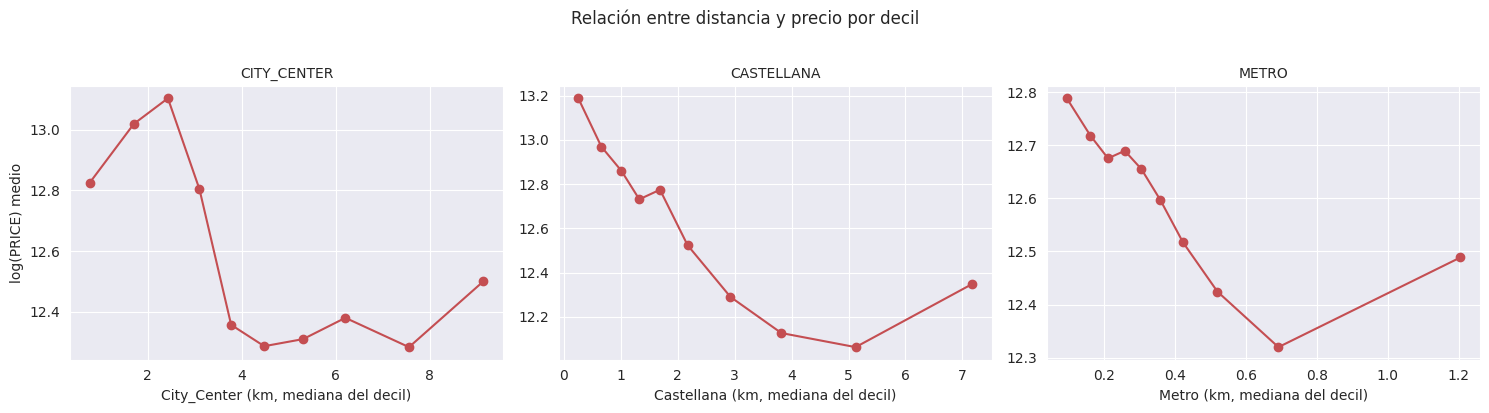

In [6]:
# ----- Perfil de log(PRICE) por decil de cada distancia: revela la forma real -----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, var in zip(axes, DISTANCIAS):
    decil = pd.qcut(train[var], q=10, duplicates="drop", labels=False)
    perfil = pd.DataFrame({
        "dist": train[var].groupby(decil).median(),
        "precio": y_log.groupby(decil).mean(),
    })
    ax.plot(perfil["dist"], perfil["precio"], marker="o", color="#c44e52")
    ax.set_xlabel(f"{var.replace('DISTANCE_TO_', '').title()} (km, mediana del decil)")
    ax.set_ylabel("log(PRICE) medio" if ax is axes[0] else "")
    ax.set_title(var.replace("DISTANCE_TO_", ""), fontsize=10)

plt.suptitle("Relación entre distancia y precio por decil", y=1.02)
plt.tight_layout()
plt.show()

Ninguna de las tres variables admite una especificación lineal satisfactoria. La
transformación logarítmica recupera el 16% de la capacidad desaprovechada en la
distancia al centro, el 49% en la distancia al eje de la Castellana y el 14% en
la distancia al metro, resultados que descartan su empleo en las tres.

El perfil de precio por decil explica el comportamiento: las curvas
correspondientes a la distancia al centro y a la distancia al metro presentan
extremos interiores —un máximo situado en el entorno de los 2,5 kilómetros en la
primera y un mínimo próximo a los 700 metros en la segunda—, formas que ninguna
transformación monótona reproduce. Se adopta en consecuencia la tramificación
para las tres variables.

#### Determinación del número de intervalos

Establecida la tramificación como forma de incorporación de las variables de
distancia, resta fijar el número de intervalos. La elección responde a un
compromiso entre capacidad explicativa recuperada y número de columnas
introducidas en el modelo: cada intervalo adicional aporta un coeficiente que
debe estimarse e interpretarse, y reduce el número de observaciones disponibles
para su estimación.

La comprobación mide la fracción de brecha recuperada para un número de
intervalos comprendido entre tres y diez, junto con la ganancia marginal
asociada a cada intervalo adicional. El criterio de decisión es la localización
del punto a partir del cual dicha ganancia marginal deja de resultar apreciable.
El límite superior de veinte intervalos empleado como techo de referencia
coincide con el que impone el criterio de representación mínima del cinco por
ciento aplicado en el análisis exploratorio.

In [7]:
# ----- Recuperación de brecha frente al número de intervalos -----
N_TRAMOS = range(3, 11)

filas = []
for var in DISTANCIAS:
    x = train[var]
    techo  = eta_cuadrado(x, y_log, 20)
    lineal = r2_lineal(x, y_log)
    brecha = techo - lineal

    for k in N_TRAMOS:
        eta = eta_cuadrado(x, y_log, k)
        filas.append({
            "Variable": var.replace("DISTANCE_TO_", ""),
            "Tramos": k,
            "eta2": eta,
            "% brecha": 100 * (eta - lineal) / brecha,
        })

curva = pd.DataFrame(filas)
tabla_curva = curva.pivot(index="Tramos", columns="Variable", values="% brecha")

print("Brecha recuperada (%)")
display(tabla_curva.round(1))

print("Ganancia marginal por intervalo adicional (puntos)")
display(tabla_curva.diff().round(1))

Brecha recuperada (%)


Variable,CASTELLANA,CITY_CENTER,METRO
Tramos,,,
3,52.3,62.2,77.6
4,69.7,42.5,80.2
5,70.8,68.9,83.1
6,75.6,70.5,83.8
7,83.4,77.2,87.2
8,84.7,79.7,89.4
9,88.2,81.8,92.4
10,89.9,83.5,94.3


Ganancia marginal por intervalo adicional (puntos)


Variable,CASTELLANA,CITY_CENTER,METRO
Tramos,,,
3,NaN,NaN,NaN
4,17.5,-19.7,2.6
5,1.1,26.4,3.0
6,4.8,1.6,0.7
7,7.8,6.6,3.4
8,1.3,2.5,2.2
9,3.5,2.2,2.9
10,1.8,1.7,1.9


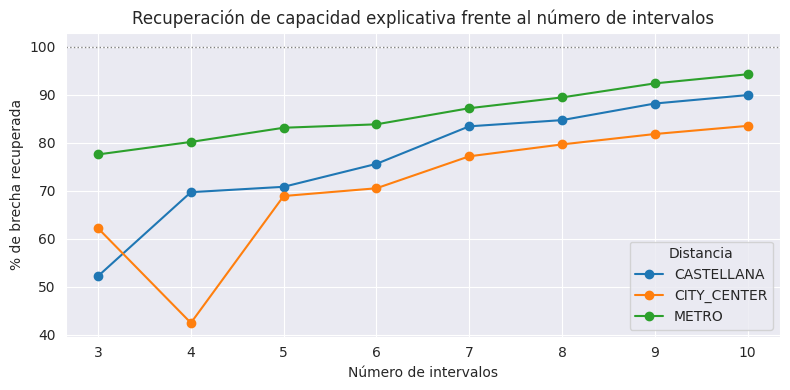

In [8]:
# ----- Curva de recuperación -----
fig, ax = plt.subplots(figsize=(8, 4))

for var, grupo in curva.groupby("Variable"):
    ax.plot(grupo["Tramos"], grupo["% brecha"], marker="o", label=var)

ax.axhline(100, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Número de intervalos")
ax.set_ylabel("% de brecha recuperada")
ax.set_title("Recuperación de capacidad explicativa frente al número de intervalos")
ax.legend(title="Distancia")
plt.tight_layout()
plt.show()

La recuperación aumenta de forma sostenida hasta los diez intervalos sin
alcanzar un punto de saturación, por lo que la evidencia no señala un número de
intervalos preferible.

La partición por cuantiles de la distancia al centro presenta además un
comportamiento no monótono: con cuatro intervalos la recuperación desciende al
42,5%, por debajo del 62,2% obtenido con tres, y se restablece al 68,9% con
cinco. El descenso obedece a que los cortes por cuantiles sitúan el máximo de
precio y el descenso posterior dentro de un mismo intervalo, donde se compensan.
El resultado desaconseja la partición por cuantiles para esta variable y motiva
el establecimiento de cortes en distancias fijas seleccionadas sobre los cambios
de pendiente del perfil.

#### Cortes adoptados

Los intervalos se establecen en distancias fijas, seleccionadas a partir de los
puntos de inflexión identificados en el perfil de precio por decil. El
procedimiento se aparta de la partición por cuantiles, habitual por su
simplicidad, atendiendo a dos consideraciones.

La primera es de ajuste. Los cortes por cuantiles se sitúan donde lo determina
el reparto de observaciones, sin relación con la localización de los cambios de
pendiente, circunstancia que en el caso de la distancia al centro produce el
comportamiento no monótono descrito.

La segunda es de explotación. Un corte establecido en una distancia fija
conserva su significado con independencia de la muestra sobre la que se aplique
el modelo, mientras que un corte por cuantiles se desplaza al variar la
composición del conjunto. Los intervalos resultantes admiten además
denominación, lo que facilita la lectura de los coeficientes del modelo lineal.

La verificación contrasta el reparto de observaciones por intervalo, con el fin
de descartar tramos de representación insuficiente, y la fracción de brecha
recuperada, comparable a la obtenida mediante partición por cuantiles.

In [9]:
# ----- Cortes fijos por significado urbano -----
CORTES = {
    "DISTANCE_TO_CITY_CENTER": [0, 1.5, 3, 5, 8, np.inf],
    "DISTANCE_TO_CASTELLANA":  [0, 1, 2.5, 4, 6, np.inf],
    "DISTANCE_TO_METRO":       [0, 0.2, 0.35, 0.5, 0.8, np.inf],
}

ETIQUETAS = {
    "DISTANCE_TO_CITY_CENTER": ["<1,5 km", "1,5-3", "3-5", "5-8", ">8 km"],
    "DISTANCE_TO_CASTELLANA":  ["<1 km", "1-2,5", "2,5-4", "4-6", ">6 km"],
    "DISTANCE_TO_METRO":       ["<200 m", "200-350", "350-500", "500-800", ">800 m"],
}

for var in DISTANCIAS:
    x = train[var]
    etiquetas = ETIQUETAS[var]
    tramo = pd.cut(x, bins=CORTES[var], labels=etiquetas, include_lowest=True)

    # Recuperación de brecha con estos cortes
    techo = eta_cuadrado(x, y_log, 20)
    lineal = r2_lineal(x, y_log)
    eta = eta_cuadrado_tramos(tramo, y_log)
    recuperado = 100 * (eta - lineal) / (techo - lineal)

    # Reparto y nivel de precio por intervalo
    n = tramo.value_counts().reindex(etiquetas)
    pct = 100 * tramo.value_counts(normalize=True).reindex(etiquetas)
    precio = train.groupby(tramo, observed=False)["PRICE"].median().reindex(etiquetas)

    resumen = pd.DataFrame({"Viviendas": n, "% del total": pct.round(1),
                            "Precio mediano": precio})
    resumen["Índice"] = (100 * precio / precio.max()).round(0)

    print("=" * 70)
    print(f"{var}   |   brecha recuperada: {recuperado:.1f}%")
    display(resumen)

DISTANCE_TO_CITY_CENTER   |   brecha recuperada: 70.8%


,Viviendas,% del total,Precio mediano,Índice
DISTANCE_TO_CITY_CENTER,,,,
"<1,5 km",3368,13.4,362000.0,82.0
"1,5-3",5055,20.1,440000.0,100.0
3-5,7007,27.9,222000.0,50.0
5-8,6829,27.2,197000.0,45.0
>8 km,2875,11.4,243000.0,55.0


DISTANCE_TO_CASTELLANA   |   brecha recuperada: 78.5%


,Viviendas,% del total,Precio mediano,Índice
DISTANCE_TO_CASTELLANA,,,,
<1 km,6172,24.6,421000.0,100.0
"1-2,5",8814,35.1,336000.0,80.0
"2,5-4",4288,17.1,182000.0,43.0
4-6,3380,13.4,158000.0,38.0
>6 km,2480,9.9,213000.0,51.0


DISTANCE_TO_METRO   |   brecha recuperada: 89.7%


,Viviendas,% del total,Precio mediano,Índice
DISTANCE_TO_METRO,,,,
<200 m,5628,22.4,332000.0,100.0
200-350,7775,30.9,292000.0,88.0
350-500,4998,19.9,249000.0,75.0
500-800,3961,15.8,208000.0,63.0
>800 m,2772,11.0,235000.0,71.0


Los cortes adoptados recuperan el 70,8%, el 78,5% y el 89,7% de la capacidad
explicativa alcanzable, superando en las tres variables a la partición por
cuantiles con igual número de intervalos, que obtiene el 68,9%, el 70,8% y el
83,1%. El intervalo de menor representación reúne el 9,9% del conjunto, muy por
encima del umbral del cinco por ciento aplicado en el análisis exploratorio, por
lo que no procede reagrupar.

El perfil de precio resultante confirma la naturaleza no monótona de las tres
relaciones. La distancia al centro alcanza su máximo en el intervalo comprendido
entre 1,5 y 3 kilómetros, que supera en un 21% al del casco histórico, y su
mínimo entre 5 y 8 kilómetros. La distancia al eje de la Castellana ordena el
precio con mayor amplitud, con un recorrido del índice entre 100 y 38, frente al
comprendido entre 100 y 63 de la distancia al metro, consistente con la menor
capacidad explicativa de esta última.

Las tres variables presentan un repunte en su intervalo más alejado. No
constituyen tres observaciones independientes sino una sola: las viviendas
distantes del centro, del eje y del metro coinciden en buena medida con las
urbanizaciones periféricas del noroeste, cuyo nivel de precio responde al tipo
de producto y no a la lejanía. La circunstancia debe tenerse presente al
interpretar los coeficientes correspondientes en el apartado 7 de la memoria.

### 2.2. Tramificación del año de construcción

El análisis exploratorio estableció que la relación entre la antigüedad del
edificio y el precio no resulta monótona: la edificación más antigua alcanza un
nivel superior al del conjunto, el mínimo se sitúa en el periodo del
desarrollismo y la edificación posterior recupera parcialmente el nivel. La
especificación lineal resulta en consecuencia inadecuada, por los mismos motivos
expuestos para las variables de distancia.

El procedimiento replica el aplicado en el apartado anterior. Se examina en
primer lugar el perfil de precio por periodo de construcción, con el fin de
localizar los cambios de nivel, y se contrastan a continuación dos conjuntos de
cortes candidatos frente al techo estimado sin imponer forma funcional, junto
con la partición por cuantiles empleada como referencia. La verificación
comprueba asimismo la representación de cada intervalo.

,Viviendas,log(PRICE) medio,Índice
CADCONSTRUCTIONYEAR,,,
"[1880, 1895)",323,12.850983,100.0
"[1895, 1910)",1128,12.782493,93.0
"[1910, 1925)",809,12.725977,88.0
"[1925, 1940)",1443,12.752294,91.0
"[1940, 1955)",2273,12.833119,98.0
"[1955, 1970)",7739,12.380591,62.0
"[1970, 1985)",5331,12.571317,76.0
"[1985, 2000)",2461,12.636073,81.0
"[2000, 2015)",3091,12.670058,83.0


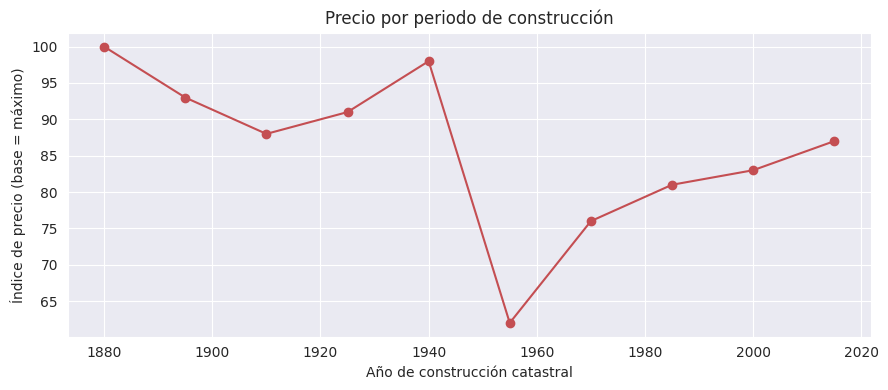

In [10]:
# ----- Perfil del precio por periodo de construcción catastral -----
anyo = train["CADCONSTRUCTIONYEAR"].dropna()
y_anyo = y_log.loc[anyo.index]

periodo = pd.cut(anyo, bins=range(1850, 2031, 15), right=False)
perfil = pd.DataFrame({
    "Viviendas": periodo.value_counts().sort_index(),
    "log(PRICE) medio": y_anyo.groupby(periodo, observed=False).mean(),
})
perfil = perfil[perfil["Viviendas"] > 50]
perfil["Índice"] = (100 * np.exp(perfil["log(PRICE) medio"])
                    / np.exp(perfil["log(PRICE) medio"]).max()).round(0)
display(perfil)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([i.left for i in perfil.index], perfil["Índice"], marker="o", color="#c44e52")
ax.set_xlabel("Año de construcción catastral")
ax.set_ylabel("Índice de precio (base = máximo)")
ax.set_title("Precio por periodo de construcción")
plt.tight_layout()
plt.show()

In [11]:
# ----- Cortes candidatos frente al techo de referencia -----
CANDIDATOS = {
    "6 intervalos": ([0, 1940, 1955, 1970, 1985, 2000, np.inf],
                     ["<1940", "1940-54", "1955-69", "1970-84", "1985-99", "2000+"]),
    "4 intervalos": ([0, 1955, 1970, 1985, np.inf],
                     ["<1955", "1955-69", "1970-84", "1985+"]),
}

techo  = eta_cuadrado(anyo, y_anyo, 20)
lineal = r2_lineal(anyo, y_anyo)
brecha = techo - lineal

print(f"Techo (η², 20 tramos): {techo:.3f}   |   Lineal (r²): {lineal:.3f}"
      f"   |   Brecha: {brecha:.3f}\n")

# Referencia: partición por cuantiles con igual número de intervalos
for k in [4, 6]:
    eta_q = eta_cuadrado(anyo, y_anyo, k)
    print(f"Cuantiles, {k} intervalos: {100*(eta_q-lineal)/brecha:>5.1f}% de brecha")
print()

for nombre, (cortes, etiquetas) in CANDIDATOS.items():
    tramo = pd.cut(anyo, bins=cortes, labels=etiquetas, right=False)
    eta = eta_cuadrado_tramos(tramo, y_anyo)

    n = tramo.value_counts().reindex(etiquetas)
    pct = 100 * tramo.value_counts(normalize=True).reindex(etiquetas)
    precio = train.loc[anyo.index].groupby(tramo, observed=False)["PRICE"].median().reindex(etiquetas)

    resumen = pd.DataFrame({"Viviendas": n, "% del total": pct.round(1),
                            "Precio mediano": precio})
    resumen["Índice"] = (100 * precio / precio.max()).round(0)

    print("=" * 70)
    print(f"{nombre}   |   brecha recuperada: {100*(eta-lineal)/brecha:.1f}%"
          f"   |   intervalo menor: {pct.min():.1f}%")
    display(resumen)

Techo (η², 20 tramos): 0.048   |   Lineal (r²): 0.002   |   Brecha: 0.045

Cuantiles, 4 intervalos:  81.7% de brecha
Cuantiles, 6 intervalos:  57.5% de brecha

6 intervalos   |   brecha recuperada: 90.9%   |   intervalo menor: 9.0%


,Viviendas,% del total,Precio mediano,Índice
CADCONSTRUCTIONYEAR,,,,
<1940,3776,15.0,320000.0,87.0
1940-54,2273,9.0,366000.0,100.0
1955-69,7739,30.8,191000.0,52.0
1970-84,5331,21.2,264000.0,72.0
1985-99,2461,9.8,294000.0,80.0
2000+,3551,14.1,299000.0,82.0


4 intervalos   |   brecha recuperada: 89.7%   |   intervalo menor: 21.2%


,Viviendas,% del total,Precio mediano,Índice
CADCONSTRUCTIONYEAR,,,,
<1955,6049,24.1,338000.0,100.0
1955-69,7739,30.8,191000.0,57.0
1970-84,5331,21.2,264000.0,78.0
1985+,6012,23.9,296000.0,88.0


Los cortes propuestos recuperan el 89,7% con cuatro intervalos y el 90,9% con
seis, frente al 81,7% y el 57,5% obtenidos mediante partición por cuantiles con
igual número de intervalos. La partición por cuantiles reproduce con seis
intervalos el mismo comportamiento no monótono observado en la distancia al
centro, lo que confirma su inadecuación para variables cuya relación con el
precio presenta extremos interiores.

Se adoptan los cuatro intervalos. Los dos adicionales aportan 1,2 puntos de
brecha, equivalentes a cinco diezmilésimas de capacidad explicativa sobre un
techo de 0,048, a cambio de dos columnas suplementarias en el modelo lineal. La
ganancia no justifica el coste. La tabla de seis intervalos muestra el motivo:
los cortes adicionales separan periodos de nivel próximo —la edificación
anterior a 1940 y la del periodo 1940-1954, con índices de 87 y 100, y la
posterior a 1985, con índices de 80 y 82—, mientras que el corte relevante, el
que aísla el periodo 1955-1969, figura en ambos conjuntos.

El perfil resultante presenta su mínimo en la edificación del periodo 1955-1969,
un 43% por debajo de la anterior a 1955, sin que la edificación posterior llegue
a recuperar dicho nivel. La antigüedad no penaliza el valor de forma progresiva:
la penalización se concentra en el producto característico del desarrollismo.

In [12]:
# ----- Cortes adoptados -----
CORTES_ANYO = [0, 1955, 1970, 1985, np.inf]
ETIQUETAS_ANYO = ["<1955", "1955-69", "1970-84", "1985+"]

# Resumen de la tramificación adoptada para el conjunto de variables
TRAMIFICACION = {**CORTES, "CADCONSTRUCTIONYEAR": CORTES_ANYO}
ETIQUETAS_TRAMOS = {**ETIQUETAS, "CADCONSTRUCTIONYEAR": ETIQUETAS_ANYO}

for var in TRAMIFICADAS:
    cortes = [c for c in TRAMIFICACION[var] if np.isfinite(c)]
    print(f"{var:<26} {len(ETIQUETAS_TRAMOS[var])} intervalos   cortes: {cortes}")

DISTANCE_TO_CITY_CENTER    5 intervalos   cortes: [0, 1.5, 3, 5, 8]
DISTANCE_TO_CASTELLANA     5 intervalos   cortes: [0, 1, 2.5, 4, 6]
DISTANCE_TO_METRO          5 intervalos   cortes: [0, 0.2, 0.35, 0.5, 0.8]
CADCONSTRUCTIONYEAR        4 intervalos   cortes: [0, 1955, 1970, 1985]


## 3. Preprocesado (memoria 5.1 y 5.2)

El preprocesado se encapsula en un objeto de `scikit-learn` que agrupa la
totalidad de las transformaciones y se ajusta exclusivamente sobre el conjunto
de entrenamiento. La decisión responde a una consideración de explotación: la
aplicación del apartado 10 carga dicho objeto y lo aplica a la vivienda
introducida por el usuario, de modo que resulta imposible que el tratamiento
recibido por los datos en producción difiera del empleado durante el
entrenamiento.

**Tratamiento de los valores ausentes.** La mayor parte de las incidencias no
requiere imputación por haberse resuelto en el análisis previo. El tipo de
vistas incorpora la ausencia como categoría propia, al constituir la falta de
declaración una circunstancia informativa. Las cinco variables con incidencias
residuales, que no superan el 0,1% del conjunto, y los dos agregados de barrio,
con
un 0,28% correspondiente a los barrios sin cobertura muestral suficiente,
se imputan por la mediana o la moda según su naturaleza. La planta, con un 4,23%
de ausentes, se imputa igualmente por la mediana.

**Calidad catastral.** Se agrupa en seis niveles mediante acotación de la escala
original, fusionando los tres superiores y los tres inferiores, y se incorpora
como variable ordinal en una única columna. La escala resultante mantiene la
monotonía respecto al precio, lo que legitima su tratamiento numérico, y la
opción responde al principio de parsimonia: entre dos especificaciones de
capacidad equivalente se adopta la que introduce menos columnas.

**Dos ramas de preprocesado.** Las variables de distancia y el año de
construcción se incorporan tramificados y estandarizados al modelo interpretable
y en su escala original al modelo de árboles con potenciación del gradiente, que
determina sus propios puntos de corte y resulta insensible a la escala. Ambas
ramas operan sobre idéntica información de partida, idéntica partición e
idéntica imputación; la diferencia se limita a la formulación que cada algoritmo
requiere, de modo que la comparación del apartado 6.4 mida la capacidad de los
modelos y no el ajuste del preprocesado a uno de ellos.

La tramificación con cortes establecidos requiere una función propia, alojada en
el módulo `tfm_preprocesado.py`. El discretizador incluido en la librería
determina los intervalos mediante criterios automáticos y no admite la
especificación de cortes. Sobrescribir los cortes del objeto una vez ajustado
tampoco resuelve el problema: la validación cruzada reajusta el preprocesado en
cada pliegue y descarta la modificación, de modo que los cortes volverían a
determinarse automáticamente en cada iteración. El módulo
acompaña al modelo serializado, dado que la referencia a la función debe
resolverse al cargarlo.

In [13]:
# ----- Módulo de transformaciones propias -----
# Se escribe desde el notebook para mantener la reproducibilidad en un único
# fichero. La función queda así en un módulo importable, condición necesaria
# para que el pipeline serializado pueda resolverla al cargarse.

MODULO = LOCAL / "tfm_preprocesado.py"

MODULO.write_text('''
"""Transformaciones del preprocesado del TFM que no tienen equivalente
en scikit-learn. Acompaña al modelo serializado."""

import numpy as np


def tramificar(X, cortes):
    """Asigna cada valor al índice del intervalo que le corresponde.

    X:      matriz (n_filas, n_columnas)
    cortes: lista de arrays, uno por columna, con los cortes interiores
    """
    return np.column_stack([
        np.digitize(X[:, i], bins=c) for i, c in enumerate(cortes)
    ])
''')

shutil.copy(MODULO, BASE / "tfm_preprocesado.py")

import sys
sys.path.insert(0, str(LOCAL))
from tfm_preprocesado import tramificar

print(f"Módulo disponible en {MODULO}")

Módulo disponible en /content/tfm/tfm_preprocesado.py


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, FunctionTransformer
)

# Los grupos de variables quedaron definidos en el apartado 2
COLUMNAS_MODELO = EXPLICATIVAS

print(f"Columnas de entrada al preprocesado: {len(COLUMNAS_MODELO)}")


Columnas de entrada al preprocesado: 35


In [15]:
# ----- Piezas comunes a las dos ramas -----

# Binarias: ausentes por la moda (incidencias residuales)
binarias = SimpleImputer(strategy="most_frequent")

# Tipo de vistas: la ausencia es categoría propia; la referencia es exterior
vistas = Pipeline([
    ("imputar", SimpleImputer(strategy="constant", fill_value=-1)),
    ("codificar", OneHotEncoder(categories=[[-1.0, 1.0, 2.0]], drop=[1.0],
                                handle_unknown="error", sparse_output=False)),
])

# Distrito: las viviendas sin cruce espacial forman categoría propia;
# la referencia es Centro (01)
distrito = Pipeline([
    ("imputar", SimpleImputer(missing_values=None, strategy="constant",
                              fill_value="SIN_ASIGNAR")),
    ("codificar", OneHotEncoder(drop=["01"], handle_unknown="ignore",
                                sparse_output=False)),
])

# Calidad catastral: acotar entre 2 y 7 fusiona los niveles 0-2 y 7-9
calidad_base = [
    ("imputar", SimpleImputer(strategy="median")),
    ("agrupar", FunctionTransformer(np.clip, kw_args={"a_min": 2, "a_max": 7},
                                    feature_names_out="one-to-one")),
]
calidad_lineal  = Pipeline(calidad_base + [("escalar", StandardScaler())])
calidad_arboles = Pipeline(calidad_base)

In [16]:
# ----- Tramificación con los cortes fijados en el apartado 2 -----

# Cortes interiores, en el orden de TRAMIFICADAS (sin el 0 ni el infinito)
CORTES_INTERIORES = [
    np.array(TRAMIFICACION[v][1:-1]) for v in TRAMIFICADAS
]

for v, c in zip(TRAMIFICADAS, CORTES_INTERIORES):
    print(f"{v:<26} {c}")

# Rama 1: tramificar y codificar los intervalos resultantes.
# La numeración de los intervalos no expresa proporcionalidad, por lo que
# requiere codificación disyuntiva y no tratamiento numérico.
tramificadas_lineal = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("tramificar", FunctionTransformer(
        tramificar,
        kw_args={"cortes": CORTES_INTERIORES},
        feature_names_out="one-to-one",
    )),
    ("codificar", OneHotEncoder(drop="first", handle_unknown="ignore",
                                sparse_output=False)),
])

# Rama 2: escala original, solo imputación
tramificadas_arboles = SimpleImputer(strategy="median")

DISTANCE_TO_CITY_CENTER    [1.5 3.  5.  8. ]
DISTANCE_TO_CASTELLANA     [1.  2.5 4.  6. ]
DISTANCE_TO_METRO          [0.2  0.35 0.5  0.8 ]
CADCONSTRUCTIONYEAR        [1955 1970 1985]


In [17]:
# ----- Las dos ramas de preprocesado -----

VISTAS   = ["FLATLOCATIONID"]
DISTRITO = ["DISTRITO"]

# Rama 1 — modelo interpretable: tramificación y estandarización
preproceso_lineal = ColumnTransformer([
    ("num",  Pipeline([("imputar", SimpleImputer(strategy="median")),
                       ("escalar", StandardScaler())]), NUMERICAS),
    ("bin",  binarias,            BINARIAS_FINAL),
    ("tram", tramificadas_lineal, TRAMIFICADAS),
    ("vis",  vistas,              VISTAS),
    ("dis",  distrito,            DISTRITO),
    ("ord",  calidad_lineal,      ORDINALES),
], remainder="drop", verbose_feature_names_out=False)

# Rama 2 — modelo de alto rendimiento: escala original
preproceso_arboles = ColumnTransformer([
    ("num",  SimpleImputer(strategy="median"), NUMERICAS),
    ("bin",  binarias,             BINARIAS_FINAL),
    ("tram", tramificadas_arboles, TRAMIFICADAS),
    ("vis",  vistas,               VISTAS),
    ("dis",  distrito,             DISTRITO),
    ("ord",  calidad_arboles,      ORDINALES),
], remainder="drop", verbose_feature_names_out=False)

print("Ramas construidas. Sin ajustar todavía.")

Ramas construidas. Sin ajustar todavía.


In [18]:
# ----- Verificación: ajuste sobre entrenamiento y nombres de columna -----

X_train = train[COLUMNAS_MODELO]
X_test  = test[COLUMNAS_MODELO]

for nombre, preproceso in [("lineal", preproceso_lineal),
                           ("árboles", preproceso_arboles)]:
    Z = preproceso.fit_transform(X_train)
    nombres = preproceso.get_feature_names_out()

    print(f"\n{'='*70}\nRama {nombre}: {X_train.shape[1]} → {Z.shape[1]} columnas")
    print(f"Ausentes tras el preprocesado: {np.isnan(Z).sum()}")
    print(f"Rango: [{Z.min():.2f}, {Z.max():.2f}]")
    print(f"\nColumnas de salida:")
    print(", ".join(nombres))


Rama lineal: 35 → 66 columnas
Ausentes tras el preprocesado: 0
Rango: [-2.47, 13.01]

Columnas de salida:
CONSTRUCTEDAREA, ROOMNUMBER, BATHNUMBER, FLOORCLEAN, CADMAXBUILDINGFLOOR, CADDWELLINGCOUNT, METRO_EN_1000M, ANUNCIOS_EN_500M, BARRIO_ANTIGUEDAD_MED, BARRIO_AREA_MED, HASTERRACE, HASLIFT, HASAIRCONDITIONING, HASPARKINGSPACE, HASNORTHORIENTATION, HASSOUTHORIENTATION, HASEASTORIENTATION, HASWESTORIENTATION, HASBOXROOM, HASWARDROBE, HASSWIMMINGPOOL, HASDOORMAN, HASGARDEN, ISDUPLEX, ISSTUDIO, ISINTOPFLOOR, BUILTTYPEID_2, BUILTTYPEID_3, DISTANCE_TO_CITY_CENTER_1, DISTANCE_TO_CITY_CENTER_2, DISTANCE_TO_CITY_CENTER_3, DISTANCE_TO_CITY_CENTER_4, DISTANCE_TO_CASTELLANA_1, DISTANCE_TO_CASTELLANA_2, DISTANCE_TO_CASTELLANA_3, DISTANCE_TO_CASTELLANA_4, DISTANCE_TO_METRO_1, DISTANCE_TO_METRO_2, DISTANCE_TO_METRO_3, DISTANCE_TO_METRO_4, CADCONSTRUCTIONYEAR_1, CADCONSTRUCTIONYEAR_2, CADCONSTRUCTIONYEAR_3, FLATLOCATIONID_-1.0, FLATLOCATIONID_2.0, DISTRITO_02, DISTRITO_03, DISTRITO_04, DISTRITO_05, 

El rango de la rama estandarizada alcanza 13,01 desviaciones típicas en su
extremo superior, magnitud que conviene no pasar por alto: procede de la
superficie construida, cuyo máximo observado es de 934 metros cuadrados. No se
depura ni se acota en este punto. Su efecto sobre la estimación se mide en el
apartado 6.3, mediante el diagnóstico de observaciones influyentes, que es la
comprobación pertinente: lo relevante no es la magnitud del valor sino si
gobierna algún coeficiente.

### 3.1. Etiquetas de presentación

El preprocesado genera nombres de columna que identifican cada intervalo por su
índice, lo que dificulta la lectura directa de los coeficientes del modelo lineal
y de las importancias estimadas. Se define a tal efecto una correspondencia entre
dichos nombres y etiquetas de lectura, aplicable únicamente en la presentación de
resultados. La correspondencia no interviene en el ajuste ni en la predicción.

In [19]:
# ----- Etiquetas legibles para la presentación de resultados -----
# El pipeline genera nombres del tipo DISTANCE_TO_METRO_2. La traducción
# se aplica únicamente al presentar coeficientes e importancias.

NOMBRES_CORTOS = {
    "DISTANCE_TO_CITY_CENTER": "Centro",
    "DISTANCE_TO_CASTELLANA":  "Castellana",
    "DISTANCE_TO_METRO":       "Metro",
    "CADCONSTRUCTIONYEAR":     "Año",
}

ETIQUETAS_LEGIBLES = {}
for var in TRAMIFICADAS:
    for i, etiqueta in enumerate(ETIQUETAS_TRAMOS[var]):
        ETIQUETAS_LEGIBLES[f"{var}_{i}"] = f"{NOMBRES_CORTOS[var]}: {etiqueta}"

ETIQUETAS_LEGIBLES.update({
    "FLATLOCATIONID_-1.0":   "Vistas: no declarado",
    "FLATLOCATIONID_2.0":    "Vistas: interior",
    "DISTRITO_SIN_ASIGNAR":  "Distrito: sin asignar",
})


def legible(nombres):
    """Traduce los nombres generados por el pipeline a etiquetas de lectura."""
    return [ETIQUETAS_LEGIBLES.get(n, n) for n in nombres]


print(legible(preproceso_lineal.get_feature_names_out())[28:45])

['Centro: 1,5-3', 'Centro: 3-5', 'Centro: 5-8', 'Centro: >8 km', 'Castellana: 1-2,5', 'Castellana: 2,5-4', 'Castellana: 4-6', 'Castellana: >6 km', 'Metro: 200-350', 'Metro: 350-500', 'Metro: 500-800', 'Metro: >800 m', 'Año: 1955-69', 'Año: 1970-84', 'Año: 1985+', 'Vistas: no declarado', 'Vistas: interior']


In [20]:
# ----- Antes y después sobre una muestra -----
muestra = X_train.sample(3, random_state=SEED)

print("ENTRADA (selección de columnas)")
display(muestra[["CONSTRUCTEDAREA", "DISTANCE_TO_CITY_CENTER",
                 "CADCONSTRUCTIONYEAR", "CADASTRALQUALITYID",
                 "FLATLOCATIONID", "DISTRITO"]])

Z = preproceso_lineal.transform(muestra)
salida = pd.DataFrame(Z, columns=preproceso_lineal.get_feature_names_out(),
                      index=muestra.index)

print("\nSALIDA rama lineal — columnas activas de cada vivienda")
for idx in salida.index:
    activas = salida.loc[idx][salida.loc[idx] != 0]
    print(f"\n{idx}: {dict(activas.round(2))}")

ENTRADA (selección de columnas)


,CONSTRUCTEDAREA,DISTANCE_TO_CITY_CENTER,CADCONSTRUCTIONYEAR,CADASTRALQUALITYID,FLATLOCATIONID,DISTRITO
15245,120,6.336989,1964.0,7.0,1.0,11
8336,220,0.210825,1950.0,3.0,1.0,01
29431,43,7.894724,2009.0,5.0,1.0,18



SALIDA rama lineal — columnas activas de cada vivienda

15245: {'CONSTRUCTEDAREA': np.float64(0.28), 'ROOMNUMBER': np.float64(0.37), 'BATHNUMBER': np.float64(0.5), 'FLOORCLEAN': np.float64(0.59), 'CADMAXBUILDINGFLOOR': np.float64(-0.13), 'CADDWELLINGCOUNT': np.float64(-0.39), 'METRO_EN_1000M': np.float64(-1.1), 'ANUNCIOS_EN_500M': np.float64(-0.63), 'BARRIO_ANTIGUEDAD_MED': np.float64(0.39), 'BARRIO_AREA_MED': np.float64(-0.56), 'HASTERRACE': np.float64(1.0), 'HASLIFT': np.float64(1.0), 'HASEASTORIENTATION': np.float64(1.0), 'HASWARDROBE': np.float64(1.0), 'BUILTTYPEID_3': np.float64(1.0), 'DISTANCE_TO_CITY_CENTER_3': np.float64(1.0), 'DISTANCE_TO_CASTELLANA_3': np.float64(1.0), 'CADCONSTRUCTIONYEAR_1': np.float64(1.0), 'DISTRITO_11': np.float64(1.0), 'CADASTRALQUALITYID': np.float64(1.57)}

8336: {'CONSTRUCTEDAREA': np.float64(1.76), 'ROOMNUMBER': np.float64(2.03), 'BATHNUMBER': np.float64(1.71), 'FLOORCLEAN': np.float64(0.13), 'CADMAXBUILDINGFLOOR': np.float64(-0.48), 'CADDWELLINGCO

### 3.2. Serialización del preprocesado

Ambas ramas se ajustan sobre el conjunto de entrenamiento y se serializan junto
con los nombres de columna del modelo, las etiquetas de presentación, los cortes
de tramificación y la semilla. **Las particiones no se guardan**: el notebook 03
las reconstruye desde el conjunto preparado con la misma semilla y verifica la
reconstrucción contra las predicciones almacenadas. El objeto constituye la
entrada de la aplicación del apartado 10, que lo carga y lo aplica a la vivienda
introducida sin reproducir ninguna de las transformaciones por su cuenta.

El módulo `tfm_preprocesado.py` acompaña al fichero serializado. La referencia a
la función de tramificación se resuelve en el momento de la carga, por lo que su
ausencia impediría recuperar el objeto.

In [21]:
# ----- Ajuste definitivo sobre entrenamiento y serialización -----

y_train = np.log(train["PRICE"])
y_test  = np.log(test["PRICE"])

preproceso_lineal.fit(X_train)
preproceso_arboles.fit(X_train)

artefactos = {
    "preproceso_lineal":   preproceso_lineal,
    "preproceso_arboles":  preproceso_arboles,
    "columnas_modelo":     COLUMNAS_MODELO,
    "etiquetas_legibles":  ETIQUETAS_LEGIBLES,
    "tramificacion":       TRAMIFICACION,
    "semilla":             SEED,
}

destino = LOCAL / "modelos" / "preprocesado.joblib"
joblib.dump(artefactos, destino)
shutil.copy(destino, BASE / "modelos" / "preprocesado.joblib")

print(f"Guardado: {destino}  ({destino.stat().st_size/1024:.0f} KB)")

# ----- Verificación de la carga -----
recuperado = joblib.load(destino)
Z = recuperado["preproceso_lineal"].transform(X_test)
print(f"Carga verificada sobre validación: {Z.shape[0]:,} x {Z.shape[1]} columnas")

Guardado: /content/tfm/modelos/preprocesado.joblib  (18 KB)
Carga verificada sobre validación: 6,284 x 66 columnas


# Bloque 4 — Protocolo de validación y métricas (memoria 6.1)

## 4.1 Esquema de validación cruzada

El conjunto de validación reservado en el bloque 1 no interviene en ninguna
decisión de modelización. La selección de familia de modelo, hiperparámetros y
tratamiento de valores ausentes se resuelve mediante validación cruzada en cinco
pliegues sobre el conjunto de entrenamiento, de modo que el error reportado en
el apartado 6.4 se estime sobre datos que no han participado en elección alguna.

Los pliegues se estratifican por decil de precio, mismo criterio aplicado a la
partición inicial, con el fin de que cada uno reproduzca la distribución de la
variable objetivo. La atención se dirige a la cola superior: un reparto
aleatorio sin estratificar admite variaciones apreciables en el número de
inmuebles de precio elevado por pliegue, que ejercen una influencia
desproporcionada sobre las métricas de error.

Los índices se fijan una única vez y se conservan en `PLIEGUES`. Todas las
configuraciones evaluadas en los bloques 6 y 7 se miden sobre los mismos
pliegues, requisito para que las diferencias observadas respondan al modelo y no
a la partición.

In [22]:
# ============================================================
# BLOQUE 4 — PROTOCOLO DE VALIDACIÓN Y MÉTRICAS (memoria 6.1)
# 4.1 Esquema de validación cruzada
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# Semilla única del notebook, declarada en el apartado 0. Gobierna la
# partición, los pliegues de validación cruzada, la búsqueda de
# hiperparámetros y los algoritmos que incorporan aleatoriedad.
SEMILLA = SEED

# --- Contrato con el bloque 3 -------------------------------------
_ESPERADOS = ["train", "test", "X_train", "X_test", "y_train", "y_test"]
_faltan = [n for n in _ESPERADOS if n not in globals()]
assert not _faltan, f"Objetos no disponibles en sesión: {_faltan}"

# --- Escala de la objetivo: se detecta, no se supone ---------------
def _a_logaritmos(y, nombre):
    """Devuelve la serie en logaritmos, venga en euros o ya transformada."""
    y = pd.Series(np.asarray(y, dtype=float)).reset_index(drop=True)
    if y.median() > 1000:                      # euros
        print(f"  {nombre}: recibido en euros, se transforma a logaritmos.")
        return np.log(y)
    print(f"  {nombre}: recibido ya en logaritmos.")
    return y

print("Escala de la variable objetivo:")
y_train_log = _a_logaritmos(y_train, "y_train")
y_test_log  = _a_logaritmos(y_test,  "y_test")

y_train_eur = np.exp(y_train_log)
y_test_eur  = np.exp(y_test_log)

assert 50_000 < y_train_eur.median() < 1_000_000, "Mediana fuera de rango plausible"
assert len(y_train_log) == len(X_train) and len(y_test_log) == len(X_test)

# --- Parámetros del protocolo -------------------------------------
N_PLIEGUES = 5
N_ESTRATOS = 10          # deciles de precio, igual criterio que la partición

estrato_cv = pd.qcut(y_train_log, q=N_ESTRATOS, labels=False)

cv = StratifiedKFold(n_splits=N_PLIEGUES, shuffle=True, random_state=SEMILLA)
idx_train = np.arange(len(y_train_log))
PLIEGUES = list(cv.split(idx_train, estrato_cv))   # fijados una sola vez

# --- Verificación ---------------------------------------------------
filas = []
for k, (i_aj, i_val) in enumerate(PLIEGUES, start=1):
    v = y_train_eur.iloc[i_val]
    filas.append({"Pliegue": k, "n ajuste": len(i_aj), "n validación": len(i_val),
                  "P10 (€)": int(v.quantile(0.10)), "Mediana (€)": int(v.median()),
                  "P90 (€)": int(v.quantile(0.90))})
resumen_pliegues = pd.DataFrame(filas)

print(f"\nEntrenamiento: {len(y_train_log):,} · Test reservado: {len(y_test_log):,}")
print(f"Validación cruzada: {N_PLIEGUES} pliegues estratificados por decil, semilla {SEMILLA}\n")
print(resumen_pliegues.to_string(index=False))

cobertura = np.concatenate([i_val for _, i_val in PLIEGUES])
assert len(cobertura) == len(idx_train) and len(np.unique(cobertura)) == len(idx_train)
print("\nCobertura verificada: cada vivienda actúa como validación exactamente una vez.")

Escala de la variable objetivo:
  y_train: recibido ya en logaritmos.
  y_test: recibido ya en logaritmos.

Entrenamiento: 25,134 · Test reservado: 6,284
Validación cruzada: 5 pliegues estratificados por decil, semilla 2018

 Pliegue  n ajuste  n validación  P10 (€)  Mediana (€)  P90 (€)
       1     20107          5027   121000       268000   813999
       2     20107          5027   121000       268000   812000
       3     20107          5027   121000       268000   812800
       4     20107          5027   121000       268000   812600
       5     20108          5026   121000       268000   813999

Cobertura verificada: cada vivienda actúa como validación exactamente una vez.


## 4.2 Batería de métricas de valoración

Todas las métricas se construyen sobre el ratio entre valoración estimada y
precio observado, magnitud que constituye la base de los estudios de valoración
masiva. El error se expresa en términos relativos, conforme a lo establecido en
el apartado 3.1: la asimetría de la variable objetivo hace que una misma
desviación en euros resulte irrelevante sobre una vivienda de precio elevado y
determinante sobre una de precio reducido.

El error relativo mediano (MdAPE) constituye la métrica principal. Las
proporciones de valoraciones comprendidas dentro de un margen del diez y del
veinte por ciento (PE10 y PE20) expresan el mismo resultado en los términos
habituales del sector. La mediana del ratio informa del sesgo global de nivel, y
el coeficiente de dispersión (COD) del estándar IAAO mide la dispersión en torno
a dicha mediana y no en torno a la unidad, lo que permite distinguir un modelo
consistente pero desplazado en su nivel de otro centrado pero errático.

Procede advertir del alcance del marco IAAO. Su origen se encuentra en la
tasación catastral con fines fiscales y presupone un denominador constituido por
precios de transacción verificados, obtenidos con posterioridad e independencia
respecto de la valoración. Aquí el denominador es el precio de oferta y procede
de la misma fuente con que se entrenó el modelo, por lo que los valores
resultantes serán optimistas frente a un estudio de ratio real. Se emplean en
consecuencia como comparación entre modelos y entre zonas, donde el sesgo afecta
por igual a todos los casos, y no como certificación frente al estándar.

La equidad vertical —esto es, si el modelo valora por exceso un segmento de
valor en perjuicio de otro— no se estima mediante los dos indicadores de
regresión que el estándar prevé, el PRD y el PRB. Ambos se retiran por sendos
sesgos de construcción que operan en direcciones opuestas y que hacen
incomparables sus valores entre modelos y entre zonas.

El primero es de endogeneidad. La fórmula del PRB regresa la desviación del
ratio contra un valor intermedio que incorpora la propia predicción, de modo que
esta figura a ambos lados de la regresión: una vivienda sobrevalorada entra en
el eje explicativo con un valor más alto, lo que induce pendiente positiva sin
que exista regresividad alguna (IAAO Statistical Tools and Measures Task Force,
2023). El segundo opera en sentido contrario: las predicciones de cualquier
modelo presentan menos dispersión que los precios observados, circunstancia que
eleva el ratio en las viviendas de precio reducido y lo reduce en las de precio
elevado, y que empuja el indicador hacia valores negativos (McMillen y Singh,
2023).

Ambos sesgos escalan con la imprecisión del modelo, de donde se sigue la
imposibilidad de comparación que motiva la retirada. Contrastar el indicador del
modelo lineal con el del modelo de árboles, de precisiones muy distintas,
equivaldría a contrastar en parte sus varianzas; y en el análisis de equidad por
zona del notebook 03, los barrios de mayor error aparentarían mayor
progresividad por construcción.

En su lugar se emplea la mediana del ratio por quintil de viviendas, ordenadas
por una magnitud ajena al error de valoración de cada una. El procedimiento no
incorpora la predicción en el ordenador y admite lectura directa, del tipo «el
quintil inferior se valora un diez por ciento por encima». El coeficiente de
dispersión se conserva, en cambio, por no presentar el problema: mide dispersión
en torno a la mediana del ratio y no pendiente contra el valor.

In [23]:
# ============================================================
# 4.2 Batería de métricas de valoración
# ============================================================

def metricas_avm(y_log_obs, y_log_pred, prefijo=""):
    """
    Métricas de valoración sobre el ratio valoración/precio.

    Recibe la objetivo y la predicción EN LOGARITMOS; opera en euros.
    No aplica corrección de retro-transformación: exp(pred) estima la
    mediana condicional del precio (véase 4.3).
    """
    obs  = np.exp(np.asarray(y_log_obs,  dtype=float))
    pred = np.exp(np.asarray(y_log_pred, dtype=float))

    ratio = pred / obs
    med_ratio = np.median(ratio)

    # --- Error relativo ------------------------------------------
    ape   = np.abs(ratio - 1.0)
    mdape = np.median(ape) * 100
    pe10  = np.mean(ape <= 0.10) * 100
    pe20  = np.mean(ape <= 0.20) * 100

    # --- Dispersión en torno a la mediana del ratio ---------------
    # COD: separa dispersión de sesgo de nivel, que mide la mediana del ratio.
    cod = np.mean(np.abs(ratio - med_ratio)) / med_ratio * 100

    # --- Control técnico en escala logarítmica --------------------
    obs_l  = np.asarray(y_log_obs,  float)
    res_log = np.asarray(y_log_pred, float) - obs_l
    mae_log = np.mean(np.abs(res_log))
    r2_log  = 1 - np.sum(res_log ** 2) / np.sum((obs_l - obs_l.mean()) ** 2)

    return pd.Series({
        f"{prefijo}MdAPE (%)":     round(mdape, 2),
        f"{prefijo}PE10 (%)":      round(pe10, 1),
        f"{prefijo}PE20 (%)":      round(pe20, 1),
        f"{prefijo}Mediana ratio": round(med_ratio, 4),
        f"{prefijo}COD":           round(cod, 2),
        f"{prefijo}MAE log":       round(mae_log, 4),
        f"{prefijo}R2 log":        round(r2_log, 4),
    })


def tabla_metricas(dic_resultados):
    """Compone una tabla comparativa a partir de {nombre: Series de métricas}."""
    return pd.DataFrame(dic_resultados).T


def ratio_por_quintil(y_log_obs, y_log_pred, ordenador, etiqueta="Quintil"):
    """
    Equidad vertical por lectura directa: mediana del ratio y error mediano
    por quintil de valor.

    `ordenador` debe ser una variable que NO contenga el error de la vivienda
    concreta (superficie, o nivel de precio de la zona). Ordenar por el precio
    observado induce sesgo: dicho precio figura a la vez en el denominador del
    ratio y en el criterio de ordenación.

    Los quintiles se definen sobre viviendas, no sobre zonas.
    """
    obs  = np.exp(np.asarray(y_log_obs,  dtype=float))
    pred = np.exp(np.asarray(y_log_pred, dtype=float))
    ratio = pred / obs

    q = pd.qcut(pd.Series(np.asarray(ordenador, dtype=float)).rank(method="first"),
                q=5, labels=[f"Q{i}" for i in range(1, 6)])

    d = pd.DataFrame({"ratio": ratio, "ape": np.abs(ratio - 1.0), "q": q})
    out = d.groupby("q", observed=True).agg(
        n=("ratio", "size"),
        ratio_mediano=("ratio", "median"),
        mdape=("ape", lambda s: s.median() * 100),
    ).round({"ratio_mediano": 4, "mdape": 2})
    out.index.name = etiqueta
    out.columns = ["n", "Ratio mediano", "MdAPE (%)"]
    return out


print("Batería de métricas definida: MdAPE, PE10, PE20, mediana del ratio, COD.")
print("Equidad vertical por tabla de quintiles (ratio_por_quintil).")

Batería de métricas definida: MdAPE, PE10, PE20, mediana del ratio, COD.
Equidad vertical por tabla de quintiles (ratio_por_quintil).


## 4.3 Criterio de selección para la validación cruzada

Conviene distinguir dos funciones que intervienen en el ajuste y que responden a
exigencias distintas. La primera es la pérdida interna del algoritmo, que guía
cada iteración del procedimiento de estimación y debe ser derivable, dado que el
algoritmo determina la dirección de mejora a partir de su derivada. La segunda
es el criterio con que se ordenan configuraciones ya estimadas, que no requiere
propiedad alguna de regularidad por limitarse a comparar valores.

El error relativo mediano no resulta admisible como pérdida interna: al tratarse
de una mediana, las modificaciones de la predicción que no afectan a la
observación central dejan la métrica inalterada, y su variación se produce a
saltos. Sí resulta admisible, en cambio, como criterio de selección. Se adopta
en consecuencia pérdida cuadrática sobre la variable en logaritmos para la
estimación, y error relativo mediano como criterio de selección en la validación
cruzada, de modo que la elección de hiperparámetros responda directamente a la
magnitud que evalúa el modelo.

La medida se calcula sobre euros, aplicando la exponencial a las predicciones.
No se aplica corrección alguna de retro-transformación: la exponencial de la
predicción estima la mediana condicional del precio, que es la magnitud
relevante para la valoración de una garantía —el valor típico del inmueble con
esas características— frente a la media condicional, desplazada al alza por la
cola superior de la distribución. La elección mantiene además la coherencia
entre la magnitud estimada y la métrica que la evalúa, dado que el error
relativo mediano es precisamente la medida que minimiza la mediana condicional.

In [24]:
# ============================================================
# 4.3 Criterio de selección para la validación cruzada
# ============================================================

from sklearn.metrics import make_scorer


def mdape_log(y_log_obs, y_log_pred):
    """
    Error relativo mediano, calculado en euros a partir de valores
    en logaritmos. Devuelve la métrica en tanto por ciento.
    """
    obs  = np.exp(np.asarray(y_log_obs,  dtype=float))
    pred = np.exp(np.asarray(y_log_pred, dtype=float))
    return float(np.median(np.abs(pred / obs - 1.0)) * 100)


# Convenio de scikit-learn: mayor es mejor. El scorer devuelve el
# MdAPE con signo negativo, de modo que la mejor configuración sea
# siempre la de puntuación más alta.
SCORER_MDAPE = make_scorer(mdape_log, greater_is_better=False)

# Scorers auxiliares, para diagnóstico en las tablas de resultados
SCORERS = {
    "MdAPE": SCORER_MDAPE,
    "MAE_log": "neg_mean_absolute_error",
    "R2_log": "r2",
}

# Parámetros comunes a toda búsqueda de hiperparámetros de los bloques 6 y 7
CV_KWARGS = dict(cv=PLIEGUES, scoring=SCORERS, refit="MdAPE", n_jobs=-1)

print("Criterio de selección: MdAPE sobre euros, calculado desde logaritmos.")
print("Scorers registrados:", ", ".join(SCORERS))
print("Los bloques 6 y 7 emplearán CV_KWARGS para que la comparación sea homogénea.")

Criterio de selección: MdAPE sobre euros, calculado desde logaritmos.
Scorers registrados: MdAPE, MAE_log, R2_log
Los bloques 6 y 7 emplearán CV_KWARGS para que la comparación sea homogénea.


## 4.4 Verificación de la batería sobre casos controlados

Las métricas definidas gobiernan la selección de modelo y la lectura del
análisis de equidad, por lo que se verifica su implementación sobre cuatro
conjuntos de predicciones construidos con resultado conocido, antes de aplicarla
a modelo alguno.

El primer caso reproduce la predicción exacta y el segundo una sobrevaloración
constante del diez por ciento, que debe registrarse como desplazamiento de nivel
sin dispersión asociada. El tercero introduce regresividad deliberada, valorando
por exceso el segmento inferior y por defecto el superior. El cuarto aplica una
perturbación aleatoria simétrica, que debe producir dispersión sin gradiente
entre segmentos de valor.

El contraste ilustra el carácter complementario de las medidas. El segundo caso
presenta un coeficiente de dispersión nulo pese a valorar por exceso la
totalidad del conjunto: el COD mide la consistencia del error y no su nivel,
que corresponde a la mediana del ratio. Un modelo puede en consecuencia
resultar consistente y sistemáticamente sesgado a un tiempo, circunstancia que
exige la lectura conjunta de ambas magnitudes.

Los dos últimos casos verifican el procedimiento adoptado para la equidad
vertical: la tabla por quintil reproduce el gradiente introducido en el tercer
caso y no registra gradiente alguno en el cuarto, donde el error carece de
estructura. La ordenación se practica sobre el valor sin perturbación, ajeno por
tanto al error de cada observación, conforme al criterio establecido en el
apartado 4.2.

In [25]:
# ============================================================
# 4.4 Verificación de la batería sobre casos controlados
# ============================================================

rng = np.random.default_rng(SEMILLA)

# Precios simulados con la forma de la distribución real (asimétrica)
obs_eur = np.exp(rng.normal(np.log(268_000), 0.55, size=8_000))
obs_l   = np.log(obs_eur)

casos = {}
casos["1. Exacta"]        = obs_l.copy()                       # predicción perfecta
casos["2. Sesgo +10%"]    = obs_l + np.log(1.10)               # nivel desplazado, sin dispersión
z = (obs_l - obs_l.mean()) / obs_l.std()
casos["3. Regresiva"]     = obs_l - 0.12 * z                   # sobrevalora lo barato
casos["4. Ruido σ=0,15"]  = obs_l + rng.normal(0, 0.15, 8_000) # dispersión sin sesgo

obtenido = tabla_metricas({k: metricas_avm(obs_l, v) for k, v in casos.items()})
cols = ["MdAPE (%)", "PE10 (%)", "PE20 (%)", "Mediana ratio", "COD"]

esperado = pd.DataFrame({
    "MdAPE (%)":     ["0", "10", "> 0", "≈ 10"],
    "PE10 (%)":      ["100", "0", "—", "≈ 50"],
    "PE20 (%)":      ["100", "100", "—", "≈ 82"],
    "Mediana ratio": ["1", "1,10", "≈ 1", "≈ 1"],
    "COD":           ["0", "0", "> 0", "> 0"],
}, index=list(casos))

print("OBTENIDO\n")
print(obtenido[cols].to_string())
print("\n\nESPERADO\n")
print(esperado.to_string())

# --- Equidad vertical: ordenador ajeno al error de la vivienda ---
# Se ordena por el precio SIN ruido, que en la simulación es observable.
quintiles_regresiva = ratio_por_quintil(obs_l, casos["3. Regresiva"], obs_l)
quintiles_ruido     = ratio_por_quintil(obs_l, casos["4. Ruido σ=0,15"], obs_l)

print("\n\nEQUIDAD VERTICAL — caso 3 (regresividad deliberada)\n")
print(quintiles_regresiva.to_string())
print("\nEQUIDAD VERTICAL — caso 4 (ruido puro)\n")
print(quintiles_ruido.to_string())

# --- Comprobaciones -------------------------------------------
o = obtenido
assert o.loc["1. Exacta", "MdAPE (%)"] == 0 and o.loc["1. Exacta", "COD"] == 0
assert abs(o.loc["2. Sesgo +10%", "MdAPE (%)"] - 10) < 0.01
assert abs(o.loc["2. Sesgo +10%", "COD"]) < 0.01           # sesgo puro: nivel sí, dispersión no
assert abs(o.loc["2. Sesgo +10%", "Mediana ratio"] - 1.10) < 0.001

r3 = quintiles_regresiva["Ratio mediano"]
assert r3.iloc[0] > 1.05 and r3.iloc[-1] < 0.95            # regresividad detectada
assert r3.is_monotonic_decreasing                          # y con gradiente ordenado

r4 = quintiles_ruido["Ratio mediano"]
assert (r4 - 1).abs().max() < 0.02                         # ruido puro: sin gradiente

print("\nVerificación superada.")
print("La tabla por quintil detecta la regresividad del caso 3 y no la inventa en el caso 4.")

OBTENIDO

                 MdAPE (%)  PE10 (%)  PE20 (%)  Mediana ratio    COD
1. Exacta             0.00     100.0     100.0         1.0000   0.00
2. Sesgo +10%        10.00       0.0     100.0         1.1000   0.00
3. Regresiva          7.97      60.2      90.1         0.9984   9.61
4. Ruido σ=0,15      10.31      48.7      81.7         1.0012  12.25


ESPERADO

                MdAPE (%) PE10 (%) PE20 (%) Mediana ratio  COD
1. Exacta               0      100      100             1    0
2. Sesgo +10%          10        0      100          1,10    0
3. Regresiva          > 0        —        —           ≈ 1  > 0
4. Ruido σ=0,15      ≈ 10     ≈ 50     ≈ 82           ≈ 1  > 0


EQUIDAD VERTICAL — caso 3 (regresividad deliberada)

            n  Ratio mediano  MdAPE (%)
Quintil                                
Q1       1600         1.1673      16.73
Q2       1600         1.0642       6.42
Q3       1600         0.9984       1.53
Q4       1600         0.9405       5.95
Q5       1600         0

# Bloque 5 — Modelos de referencia (memoria 6.1)

## 5.1 Construcción de los modelos de referencia

Los procedimientos de referencia delimitan la exigencia aplicable al modelo:
estiman el valor mediante la aplicación de un precio unitario de zona a la
superficie del inmueble, procedimiento habitual en ausencia de sistema de
valoración. Su superación constituye la condición mínima para que un sistema
automatizado justifique su complejidad.

Se construyen tres niveles de agregación espacial sobre idéntica fórmula: global,
por distrito y por barrio. El primero prescinde de la localización; el segundo
reproduce la información espacial de que dispone el modelo, que incorpora el
distrito como variable explicativa y descarta el barrio; el tercero emplea la
máxima granularidad disponible. La comparación entre los tres niveles cuantifica
la aportación de la localización con independencia del resto de características.

El precio unitario se resume mediante la mediana, por la misma razón que motiva
el empleo del error relativo mediano como métrica: la media resultaría desplazada
por los registros de precio elevado de cada zona. Las medianas se estiman
exclusivamente sobre el conjunto de entrenamiento, de modo que el precio de las
viviendas de validación no intervenga en la construcción del procedimiento con el
que posteriormente se valoran.

Las zonas que no alcanzan el umbral de treinta viviendas establecido en el
apartado 3.2 reciben el precio unitario mediano de su distrito, al no resultar
estimable con suficiencia el agregado propio.

**Una asimetría que conviene declarar.** El procedimiento de referencia emplea
el precio de las viviendas del entorno, que es precisamente la información que
el apartado 2 excluyó del modelo por constituir fuga. La diferencia está en
cómo se emplea: aquí las medianas se estiman exclusivamente sobre el conjunto de
entrenamiento, de modo que ninguna vivienda de validación contribuye al agregado
con que después se valora, y el procedimiento es en consecuencia legítimo. Pero
la referencia dispone así de una información que al modelo se le negó de forma
deliberada, y que además es la de mayor capacidad explicativa del conjunto. La
comparación del apartado 6.4 debe leerse con esa desventaja presente: si el
modelo supera a la referencia de barrio, lo hace compensando con enriquecimiento
geoespacial el agregado de zona del que no dispone.

In [26]:
# ============================================================
# BLOQUE 5 — MODELOS DE REFERENCIA (memoria 6.1)
# 5.1 Construcción sobre entrenamiento
# ============================================================

MIN_VIVIENDAS_ZONA = 30      # umbral del apartado 3.2

# --- Coherencia entre train y y_train ------------------------------
assert (train.index == X_train.index).all(), "Índices de train y X_train desalineados"
_dif = (np.exp(y_train.values) - train["PRICE"].values) / train["PRICE"].values
assert np.abs(_dif).max() < 1e-9, "exp(y_train) no reproduce PRICE: revisar alineación"
print(f"Alineación verificada: exp(y_train) reproduce PRICE "
      f"(desviación máxima {np.abs(_dif).max():.2e}).\n")

# --- Precio unitario observado en entrenamiento --------------------
pu_train = train["PRICE"] / train["CONSTRUCTEDAREA"]

# --- Nivel 1: global -----------------------------------------------
PU_GLOBAL = float(pu_train.median())

# --- Nivel 2: distrito (21 unidades, misma granularidad que el modelo)
pu_distrito = pu_train.groupby(train["DISTRITO"]).median()
n_distrito  = pu_train.groupby(train["DISTRITO"]).size()

# --- Nivel 3: barrio (135 unidades) --------------------------------
pu_barrio = pu_train.groupby(train["LOCATIONNAME"]).median()
n_barrio  = pu_train.groupby(train["LOCATIONNAME"]).size()

# Barrios por debajo del umbral: se sustituyen por la mediana de su distrito
distrito_de_barrio = train.groupby("LOCATIONNAME")["DISTRITO"].first()
barrios_escasos = n_barrio[n_barrio < MIN_VIVIENDAS_ZONA].index
pu_barrio_ajustado = pu_barrio.copy()
pu_barrio_ajustado.loc[barrios_escasos] = (
    distrito_de_barrio.loc[barrios_escasos].map(pu_distrito).values
)

# --- Resumen --------------------------------------------------------
print(f"Precio unitario mediano global: {PU_GLOBAL:,.0f} €/m²")
print(f"Distritos: {len(pu_distrito)} · recorrido "
      f"{pu_distrito.min():,.0f} – {pu_distrito.max():,.0f} €/m² "
      f"(factor {pu_distrito.max()/pu_distrito.min():.2f})")
print(f"Barrios:   {len(pu_barrio)} · recorrido "
      f"{pu_barrio.min():,.0f} – {pu_barrio.max():,.0f} €/m² "
      f"(factor {pu_barrio.max()/pu_barrio.min():.2f})")

print(f"\nBarrios con menos de {MIN_VIVIENDAS_ZONA} viviendas en entrenamiento: "
      f"{len(barrios_escasos)} ({n_barrio[barrios_escasos].sum()} viviendas, "
      f"{n_barrio[barrios_escasos].sum()/len(train)*100:.2f}%)")
if len(barrios_escasos):
    print(pd.DataFrame({
        "n": n_barrio[barrios_escasos],
        "Distrito": distrito_de_barrio.loc[barrios_escasos],
        "PU sustituido (€/m²)": pu_barrio_ajustado[barrios_escasos].round(0),
    }).to_string())

Alineación verificada: exp(y_train) reproduce PRICE (desviación máxima 9.77e-16).

Precio unitario mediano global: 3,571 €/m²
Distritos: 21 · recorrido 1,645 – 5,578 €/m² (factor 3.39)
Barrios:   135 · recorrido 1,243 – 7,574 €/m² (factor 6.09)

Barrios con menos de 30 viviendas en entrenamiento: 8 (123 viviendas, 0.49%)
                    n Distrito  PU sustituido (€/m²)
LOCATIONNAME                                        
Aeropuerto         14       21                3351.0
Arroyo del Fresno  24       08                3490.0
Atalaya            27       15                2944.0
Cuatro Vientos      4       10                2234.0
El Pardo            6       08                3490.0
El Plantío         13       09                4124.0
Horcajo            11       14                2468.0
Palomas            24       16                3605.0


## 5.2 Evaluación sobre el conjunto de validación

Los tres procedimientos se aplican a las 6.284 viviendas reservadas, empleando
la superficie de cada inmueble y el precio unitario mediano estimado para su
zona sobre el conjunto de entrenamiento. La evaluación se practica con la
batería de métricas del bloque 4, de modo que las cifras resulten directamente
comparables con las de los modelos de los bloques 6 y 7.

Las magnitudes obtenidas sustituyen a las estimaciones preliminares calculadas
sobre el conjunto completo en el notebook de análisis exploratorio, que
incorporaban el precio de las viviendas de validación en los agregados con que
posteriormente se valoraban.

La diferencia entre los tres niveles cuantifica la aportación de la localización
con independencia del resto de características de la vivienda. El nivel de
distrito reviste particular interés por reproducir la información espacial de
que dispone el modelo, lo que permite contrastar en qué medida el
enriquecimiento geoespacial compensa la ausencia del barrio como variable
explicativa.

Se incorpora asimismo la distribución del ratio por quintil de superficie para
el procedimiento de mayor exigencia, ordenación practicada sobre una variable
ajena al error de valoración de cada vivienda. La lectura resulta pertinente por
construcción: un procedimiento que estima el valor como producto de la
superficie por un precio unitario constante de zona no reproduce la relación no
proporcional entre superficie y precio documentada en el apartado 3.1, donde la
elasticidad estimada asciende a 1,14.

In [27]:
# ============================================================
# 5.2 Aplicación a validación y evaluación
# ============================================================

# --- Precio unitario asignado a cada vivienda de test ---------------
# Ninguna de estas cifras procede del conjunto de validación.
pu_asignado_distrito = test["DISTRITO"].map(pu_distrito)
pu_asignado_barrio   = test["LOCATIONNAME"].map(pu_barrio_ajustado)

# Zonas presentes en validación y ausentes en entrenamiento → mediana global.
# Rama defensiva: la partición estratificada no debería activarla.
n_sin_distrito = int(pu_asignado_distrito.isna().sum())
n_sin_barrio   = int(pu_asignado_barrio.isna().sum())
pu_asignado_distrito = pu_asignado_distrito.fillna(PU_GLOBAL)
pu_asignado_barrio   = pu_asignado_barrio.fillna(PU_GLOBAL)

if n_sin_distrito or n_sin_barrio:
    print(f"Zonas sin agregado en entrenamiento → mediana global: "
          f"{n_sin_distrito} por distrito, {n_sin_barrio} por barrio.")
else:
    print("Todas las zonas de validación disponen de agregado estimado en entrenamiento.")

# --- Valoración = precio unitario de zona × superficie ---------------
sup_test = test["CONSTRUCTEDAREA"].values
referencias_log = {
    "Ref. superficie (global)": np.log(PU_GLOBAL * sup_test),
    "Ref. distrito (21)":       np.log(pu_asignado_distrito.values * sup_test),
    "Ref. barrio (135)":        np.log(pu_asignado_barrio.values * sup_test),
}

# --- Métricas sobre las 6.284 viviendas de validación -----------------
RESULTADOS = {n: metricas_avm(y_test.values, p) for n, p in referencias_log.items()}
tabla_referencias = tabla_metricas(RESULTADOS)

print(f"\nEvaluación sobre {len(test):,} viviendas de validación\n")
print(tabla_referencias[["MdAPE (%)", "PE10 (%)", "PE20 (%)",
                         "Mediana ratio", "COD"]].to_string())

# --- Aportación de la localización -------------------------------------
m = tabla_referencias["MdAPE (%)"]
print(f"\nAportación de la localización sobre la referencia global:")
print(f"  Distrito: {m.iloc[0]:.2f}% → {m.iloc[1]:.2f}%  "
      f"(reducción del {(1 - m.iloc[1]/m.iloc[0])*100:.1f}%)")
print(f"  Barrio:   {m.iloc[0]:.2f}% → {m.iloc[2]:.2f}%  "
      f"(reducción del {(1 - m.iloc[2]/m.iloc[0])*100:.1f}%)")

# --- Equidad vertical de la referencia exigente -------------------------
# Ordenado por superficie: variable ajena al error de la vivienda.
print("\nRatio por quintil de superficie — referencia de barrio\n")
print(ratio_por_quintil(y_test.values, referencias_log["Ref. barrio (135)"],
                        sup_test, etiqueta="Quintil de superficie").to_string())

Todas las zonas de validación disponen de agregado estimado en entrenamiento.

Evaluación sobre 6,284 viviendas de validación

                          MdAPE (%)  PE10 (%)  PE20 (%)  Mediana ratio    COD
Ref. superficie (global)      33.71      14.0      29.0         1.0100  45.79
Ref. distrito (21)            17.76      30.1      54.9         1.0099  22.85
Ref. barrio (135)             14.75      35.4      63.2         1.0005  19.89

Aportación de la localización sobre la referencia global:
  Distrito: 33.71% → 17.76%  (reducción del 47.3%)
  Barrio:   33.71% → 14.75%  (reducción del 56.2%)

Ratio por quintil de superficie — referencia de barrio

                          n  Ratio mediano  MdAPE (%)
Quintil de superficie                                
Q1                     1257         0.9326      15.10
Q2                     1257         1.0115      13.46
Q3                     1256         1.0312      13.53
Q4                     1257         1.0044      15.77
Q5                 

Los tres niveles de agregación cuantifican la aportación de la localización con
independencia del resto de características: conocer el barrio reduce el error de
valoración en un 56,2% respecto de la estimación que prescinde de la ubicación.
El nivel intermedio reviste interés particular por reproducir la información
espacial de que dispone el modelo, que incorpora el distrito y descarta el
barrio: el salto entre ambos niveles asciende a tres puntos porcentuales, magnitud
que el modelo habrá de compensar mediante el enriquecimiento geoespacial.

El coeficiente de dispersión del procedimiento de mayor exigencia asciende a
19,89, por encima del valor de quince que el estándar del sector considera
admisible en mercado residencial. La regla elemental no solo resulta imprecisa
sino inconsistente entre inmuebles comparables, circunstancia que delimita un
segundo margen de mejora además del error agregado.

La distribución del ratio por quintil de superficie revela asimismo un sesgo
sistemático por tamaño, con infravaloración del 6,7% en el quintil inferior y
sobrevaloración del 3,8% en el superior. El comportamiento es consecuencia
necesaria de la formulación empleada: aplicar un precio unitario constante a
cada zona supone asumir proporcionalidad entre superficie y precio, cuando la
elasticidad estimada en el apartado 3.1 asciende a 1,14.

# Bloque 6 — Modelo interpretable (memoria 6.2)

## 6.1 Ajuste del modelo interpretable y diagnóstico de colinealidad

El modelo interpretable se estima mediante regresión lineal múltiple por mínimos
cuadrados ordinarios sobre la rama lineal del preprocesado, que incorpora las
variables no monótonas tramificadas y las continuas estandarizadas. La elección
responde a que dicha especificación constituye el procedimiento habitual en
valoración masiva, ámbito del que procede el marco metodológico adoptado en el
apartado 4.2, y a que proporciona inferencia estándar sobre los coeficientes,
propiedad que la regularización no conserva.

El diagnóstico de colinealidad se practica mediante los factores de inflación de
varianza, que cuantifican en qué medida la varianza estimada de cada coeficiente
resulta amplificada por su relación con el resto de columnas del diseño. La
comprobación reviste interés por la estructura de este último: la tramificación
genera indicadores contiguos correlacionados por construcción, si bien la
exclusión de una categoría de referencia por variable elimina la dependencia
exacta que impediría la estimación.

La especificación no se modifica en función de la significación estadística de
los coeficientes. La selección de variables se resolvió en el apartado 5
atendiendo a criterios de fuga de información, redundancia y pertinencia para el
negocio, y sobre veinticinco mil observaciones el contraste de significación
distingue efectos de magnitud irrelevante. Los valores de significación se
comunican con finalidad diagnóstica, no como criterio de depuración.

In [28]:
# ============================================================
# BLOQUE 6 — MODELO INTERPRETABLE (memoria 6.2)
# 6.1 Ajuste y diagnóstico de colinealidad
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import statsmodels.api as sm

# --- Modelo: preprocesado + mínimos cuadrados ordinarios ------------
modelo_lineal = Pipeline([
    ("preproceso", preproceso_lineal),
    ("regresion",  LinearRegression()),
])
modelo_lineal.fit(X_train, y_train)

nombres = modelo_lineal.named_steps["preproceso"].get_feature_names_out()
Z_train = modelo_lineal.named_steps["preproceso"].transform(X_train)
print(f"Diseño: {Z_train.shape[0]:,} observaciones × {Z_train.shape[1]} columnas\n")

# --- Diagnóstico de colinealidad: factores de inflación de varianza --
# VIF_j = 1 / (1 - R²_j), siendo R²_j el ajuste de la columna j sobre
# el resto. Se obtiene de la diagonal de la inversa de la matriz de
# correlaciones, sin necesidad de estimar 66 regresiones auxiliares.
R = np.nan_to_num(np.corrcoef(Z_train, rowvar=False), nan=0.0)
np.fill_diagonal(R, 1.0)
vif = np.diag(np.linalg.pinv(R))

diag_vif = (pd.DataFrame({"Columna": nombres, "VIF": vif})
              .sort_values("VIF", ascending=False)
              .reset_index(drop=True))

print("Factores de inflación de varianza — diez valores más altos\n")
print(diag_vif.head(10).round(2).to_string(index=False))
print(f"\nColumnas con VIF > 10: {(diag_vif['VIF'] > 10).sum()} de {len(diag_vif)}")
print(f"Columnas con VIF > 5:  {(diag_vif['VIF'] > 5).sum()}")

# --- Inferencia sobre los coeficientes -------------------------------
Z_sm = sm.add_constant(Z_train, has_constant="add")
ols_sm = sm.OLS(y_train.values, Z_sm).fit()

inferencia = pd.DataFrame({
    "Columna": ["(constante)"] + list(nombres),
    "Coef": ols_sm.params,
    "EE":   ols_sm.bse,
    "t":    ols_sm.tvalues,
    "p":    ols_sm.pvalues,
})

print(f"\nR² sobre logaritmos (entrenamiento): {ols_sm.rsquared:.4f}")
print(f"Coeficientes con p > 0,05: "
      f"{int((inferencia['p'] > 0.05).sum())} de {len(inferencia)}")

Diseño: 25,134 observaciones × 66 columnas

Factores de inflación de varianza — diez valores más altos

                  Columna   VIF
DISTANCE_TO_CITY_CENTER_3 19.37
DISTANCE_TO_CITY_CENTER_2 16.66
DISTANCE_TO_CITY_CENTER_4 13.47
DISTANCE_TO_CITY_CENTER_1 11.08
              DISTRITO_11  9.40
    BARRIO_ANTIGUEDAD_MED  8.93
              DISTRITO_04  8.55
              DISTRITO_13  8.53
              DISTRITO_15  8.25
              DISTRITO_06  7.96

Columnas con VIF > 10: 4 de 66
Columnas con VIF > 5:  25

R² sobre logaritmos (entrenamiento): 0.8962
Coeficientes con p > 0,05: 12 de 67


## 6.2 Lectura de los coeficientes

La estimación sobre el logaritmo del precio permite traducir cada coeficiente a
un efecto porcentual: un valor estimado de 0,12 equivale a un incremento del
12,7% sobre el precio del inmueble, con independencia de su nivel. La propiedad
constituye la ventaja interpretativa de la formulación logarítmica y permite
comunicar los resultados en términos directamente comprensibles.

Los coeficientes de las variables continuas se expresan sobre magnitudes
estandarizadas, de modo que representan el efecto asociado a una desviación
típica de la variable. Los de las variables tramificadas se interpretan frente al
tramo de referencia excluido en la codificación, y los de distrito frente al
distrito Centro.

La lectura de los coeficientes correspondientes a variables afectadas por
colinealidad elevada requiere cautela. El reparto del efecto conjunto entre
tramos contiguos de una misma variable, o entre variables que miden aspectos
próximos de la localización, no resulta unívoco, si bien la capacidad predictiva
del conjunto no se ve comprometida. El control de signos verifica que los
atributos que añaden valor de forma inequívoca presenten efecto positivo, lo que
constituye una comprobación de coherencia del modelo con el conocimiento del
mercado.

In [29]:
# ============================================================
# 6.2 Lectura de los coeficientes
# ============================================================

# El modelo estima el logaritmo del precio: un coeficiente b se traduce
# en un efecto multiplicativo de exp(b) - 1 sobre el precio en euros.
coef = inferencia.iloc[1:].copy()          # se excluye la constante
coef["Etiqueta"] = coef["Columna"].map(lambda c: ETIQUETAS_LEGIBLES.get(c, c))
coef["Efecto (%)"] = (np.exp(coef["Coef"]) - 1) * 100
coef["Signif."] = np.where(coef["p"] < 0.05, "", "n.s.")

def _bloque(c):
    if c.startswith("DISTRITO"):                    return "Distrito"
    if c.startswith(("DISTANCE_", "METRO_EN", "ANUNCIOS_EN")): return "Localización"
    if c.startswith("BARRIO_"):                     return "Contexto de barrio"
    # La tipología describe qué clase de vivienda es, no qué tiene: el tipo de
    # obra, el dúplex, el estudio y el ático. Se separa del equipamiento, que
    # recoge los atributos que la vivienda incorpora.
    if c.startswith(("BUILTTYPE", "ISDUPLEX", "ISSTUDIO", "ISINTOPFLOOR")):
        return "Tipología"
    if c.startswith(("HAS", "IS")):                 return "Equipamiento"
    if c.startswith(("FLATLOCATIONID", "FLOORCLEAN", "CADMAXBUILDING")): return "Posición"
    return "Vivienda"

coef["Bloque"] = coef["Columna"].map(_bloque)

# --- Efectos de mayor magnitud --------------------------------------
top = coef.reindex(coef["Efecto (%)"].abs().sort_values(ascending=False).index)
print("Coeficientes de mayor magnitud\n")
print(top.head(20)[["Etiqueta", "Bloque", "Efecto (%)", "p", "Signif."]]
      .round({"Efecto (%)": 2, "p": 4}).to_string(index=False))

# --- Equipamiento: lectura directa en porcentaje ----------------------
equip = (coef[coef["Bloque"].isin(["Equipamiento", "Tipología"])]
         .sort_values("Efecto (%)", ascending=False))
print("\n\nAtributos de la vivienda — efecto sobre el precio\n")
print(equip[["Etiqueta", "Efecto (%)", "p", "Signif."]]
      .round({"Efecto (%)": 2, "p": 4}).to_string(index=False))

# --- Coeficientes no significativos -----------------------------------
ns = coef[coef["p"] > 0.05].sort_values("p")
print(f"\n\nCoeficientes no significativos al 5% ({len(ns)})\n")
print(ns[["Etiqueta", "Bloque", "Efecto (%)", "p"]]
      .round({"Efecto (%)": 2, "p": 3}).to_string(index=False))

# --- Control de signos frente a lo esperado ----------------------------
esperado_positivo = ["HASLIFT", "HASAIRCONDITIONING", "HASPARKINGSPACE",
                     "HASSWIMMINGPOOL", "HASDOORMAN", "HASGARDEN", "HASTERRACE",
                     "CONSTRUCTEDAREA", "BATHNUMBER"]
control = coef[coef["Columna"].isin(esperado_positivo)]
anomalos = control[control["Coef"] < 0]
if len(anomalos):
    print("\n\nAVISO — signo contrario al esperado:\n")
    print(anomalos[["Etiqueta", "Efecto (%)", "p"]].round(2).to_string(index=False))
else:
    print("\n\nControl de signos: todos los atributos de valor añadido "
          "presentan efecto positivo.")

Coeficientes de mayor magnitud

       Etiqueta       Bloque  Efecto (%)   p Signif.
    DISTRITO_17     Distrito      -45.41 0.0        
    DISTRITO_13     Distrito      -42.06 0.0        
    DISTRITO_19     Distrito      -41.98 0.0        
    DISTRITO_12     Distrito      -40.00 0.0        
    DISTRITO_18     Distrito      -39.21 0.0        
    DISTRITO_11     Distrito      -37.05 0.0        
    DISTRITO_10     Distrito      -32.38 0.0        
CONSTRUCTEDAREA     Vivienda       31.42 0.0        
    DISTRITO_20     Distrito      -26.44 0.0        
    DISTRITO_14     Distrito      -26.03 0.0        
  Centro: >8 km Localización      -24.17 0.0        
  BUILTTYPEID_2    Tipología      -23.33 0.0        
    Centro: 5-8 Localización      -22.56 0.0        
        HASLIFT Equipamiento       19.00 0.0        
    DISTRITO_04     Distrito       16.82 0.0        
    Centro: 3-5 Localización      -16.46 0.0        
  BUILTTYPEID_3    Tipología      -16.19 0.0        
    DISTRITO_0

## 6.3 Diagnóstico de observaciones influyentes

El análisis descriptivo identificó un registro cuyo valor se aparta trece
desviaciones típicas de la media en una de las variables continuas. Dado que la
estimación por mínimos cuadrados no incorpora mecanismo alguno de contención
frente a observaciones extremas, procede verificar si dicho registro, o
cualquier otro, ejerce una influencia desproporcionada sobre los coeficientes.

El diagnóstico combina dos magnitudes. El apalancamiento mide cuánto se aparta
una observación del centro del espacio de las variables explicativas, con
independencia de su precio: una vivienda de características inusuales presenta
apalancamiento elevado aunque el modelo la valore correctamente. La distancia de
Cook combina apalancamiento y residuo, y cuantifica en qué medida variarían los
coeficientes estimados si la observación se excluyera del ajuste. Una
observación extrema pero bien predicha no resulta problemática; lo es aquella
que además obliga al modelo a desplazarse para acomodarla.

El criterio de intervención se establece con anterioridad al examen de los
resultados: solo se considerará el tratamiento de un registro cuando su
exclusión altere de forma apreciable los coeficientes estimados y se disponga
además de fundamento sustantivo para considerarlo erróneo. La condición
descarta la

In [30]:
# ============================================================
# 6.3 Diagnóstico de observaciones influyentes
# ============================================================

infl = ols_sm.get_influence()
apalancamiento = infl.hat_matrix_diag
cook = infl.cooks_distance[0]
residuo_est = infl.resid_studentized_internal

n, p = Z_sm.shape
umbral_apal = 2 * p / n            # criterio habitual: 2·(k+1)/n
umbral_cook = 4 / n                # criterio habitual: 4/n

diag = pd.DataFrame({
    "idx": train.index,
    "Precio (€)": np.exp(y_train.values).round(0),
    "Superficie": train["CONSTRUCTEDAREA"].values,
    "Barrio": train["LOCATIONNAME"].values,
    "Apalancamiento": apalancamiento,
    "Cook": cook,
    "Residuo est.": residuo_est,
})

print(f"Observaciones: {n:,} · Parámetros: {p}")
print(f"Umbral de apalancamiento (2p/n): {umbral_apal:.5f} "
      f"→ {int((apalancamiento > umbral_apal).sum()):,} por encima")
print(f"Umbral de Cook (4/n): {umbral_cook:.5f} "
      f"→ {int((cook > umbral_cook).sum()):,} por encima")
print(f"Distancia de Cook máxima: {cook.max():.4f}")

print("\n\nDiez observaciones de mayor influencia\n")
print(diag.nlargest(10, "Cook")[
    ["Precio (€)", "Superficie", "Barrio", "Apalancamiento", "Cook", "Residuo est."]
].round({"Apalancamiento": 4, "Cook": 4, "Residuo est.": 2}).to_string(index=False))

print("\n\nDiez observaciones de mayor apalancamiento\n")
print(diag.nlargest(10, "Apalancamiento")[
    ["Precio (€)", "Superficie", "Barrio", "Apalancamiento", "Cook", "Residuo est."]
].round({"Apalancamiento": 4, "Cook": 4, "Residuo est.": 2}).to_string(index=False))

# --- Efecto real de excluir las observaciones más influyentes ---------
K = 20
descartar = diag.nlargest(K, "Cook").index.values
mantener = np.setdiff1d(np.arange(n), descartar)

ols_sin = sm.OLS(y_train.values[mantener], Z_sm[mantener]).fit()
cambio = np.abs(ols_sm.params - ols_sin.params)
cambio_rel = cambio / (np.abs(ols_sm.params) + 1e-8) * 100

print(f"\n\nEfecto de excluir las {K} observaciones de mayor influencia\n")
print(f"  Cambio absoluto máximo en un coeficiente: {cambio.max():.4f}")
print(f"  Coeficiente afectado: "
      f"{(['(constante)'] + list(nombres))[int(np.argmax(cambio))]}")
print(f"  Cambio relativo mediano: {np.median(cambio_rel):.2f}%")
print(f"  Coeficientes con cambio de signo: "
      f"{int(np.sum(np.sign(ols_sm.params) != np.sign(ols_sin.params)))}")
print(f"  R² con todas / sin ellas: {ols_sm.rsquared:.4f} / {ols_sin.rsquared:.4f}")

Observaciones: 25,134 · Parámetros: 67
Umbral de apalancamiento (2p/n): 0.00533 → 560 por encima
Umbral de Cook (4/n): 0.00016 → 1,267 por encima
Distancia de Cook máxima: 0.0128


Diez observaciones de mayor influencia

 Precio (€)  Superficie                  Barrio  Apalancamiento   Cook  Residuo est.
  1544000.0         749                 Almagro          0.0070 0.0128        -11.00
  2780000.0         801    Lavapiés-Embajadores          0.0197 0.0094         -5.58
  8133000.0         934                 El Viso          0.0124 0.0085         -6.73
  1192000.0         638              Mirasierra          0.0089 0.0053         -6.29
  2732000.0         928                 Chopera          0.0265 0.0052         -3.59
  4626000.0         760               Recoletos          0.0073 0.0052         -6.85
  2493000.0         385           Puerta Bonita          0.0056 0.0051          7.77
    59000.0          70          Cuatro Caminos          0.0047 0.0041         -7.64
  1258000.0   

El diagnóstico descarta la existencia de observaciones que gobiernen la
estimación. La distancia de Cook máxima asciende a 0,0128, casi dos órdenes
de magnitud por debajo del valor unitario que se considera indicativo de influencia
severa, y la exclusión de las veinte observaciones de mayor influencia altera el
coeficiente más afectado en 0,0139 —equivalente a un efecto del 1,4% sobre el
precio— sin que ninguno modifique su signo.

Siete de las diez observaciones de mayor influencia corresponden a inmuebles de
superficie excepcional, entre 638 y 934 metros cuadrados, y en las siete el
residuo resulta negativo: el modelo **sobrestima** su valor. El comportamiento
se sigue de la elasticidad única estimada entre superficie y precio, superior a
la unidad, que al extrapolarse al extremo del rango produce valoraciones por
encima del precio observado. No constituyen errores de registro sino información
legítima sobre el segmento superior del mercado, precisamente aquel de mayor
exposición en términos de riesgo de crédito, por lo que se conservan. La
sobrestimación en ese extremo reaparece en el error por decil del apartado 6.5.

Las tres restantes obedecen a otra causa. Son viviendas de superficie ordinaria
—70, 180 y 385 metros cuadrados— cuyo precio se aparta del que sus
características predicen, con residuos estandarizados próximos a ocho
desviaciones típicas en valor absoluto. La circunstancia puede obedecer a
errores de registro o a cargas no declaradas sobre el inmueble, y acota el error
mínimo alcanzable por cualquier modelo con independencia de su especificación. Su
influencia sobre la estimación resulta despreciable, y su exclusión exigiría un
criterio basado en la propia variable objetivo que no resultaría replicable en
explotación.

## 6.4 Aportación de los bloques de variables

La especificación del modelo agrupa variables de naturaleza heterogénea, cuya
obtención comporta costes distintos. Las características físicas del inmueble
figuran en cualquier registro de anuncio; el distrito requiere únicamente la
dirección; el enriquecimiento geoespacial del apartado 4 exige el cálculo de
distancias a puntos de interés y la construcción de agregados de entorno, con la
infraestructura de datos que ello comporta en explotación.

Procede en consecuencia cuantificar la aportación de cada bloque al error de
valoración, mediante especificaciones acumulativas evaluadas por validación
cruzada sobre el conjunto de entrenamiento. El procedimiento difiere de la
selección automática de variables descartada en el apartado 6.1: no se persigue
identificar la combinación óptima de predictores, sino medir el rendimiento
marginal de conjuntos definidos por criterio sustantivo y por coste de
obtención.

El resultado informa una decisión de explotación. Un bloque cuya aportación
resulte reducida frente al coste de mantener su infraestructura de datos puede
omitirse en una primera versión del sistema, o reservarse para una fase
posterior.

In [31]:
# ============================================================
# 6.4 Aportación de los bloques de variables
# ============================================================

import copy
from sklearn.model_selection import cross_val_score

# --- Bloques definidos por criterio sustantivo -----------------------
ORIENTACIONES = ["HASNORTHORIENTATION", "HASSOUTHORIENTATION",
                 "HASEASTORIENTATION", "HASWESTORIENTATION"]

BLOQUE_DISTRITO = ["DISTRITO"]
BLOQUE_GEO      = ["DISTANCE_TO_CITY_CENTER", "DISTANCE_TO_CASTELLANA",
                   "DISTANCE_TO_METRO", "METRO_EN_1000M", "ANUNCIOS_EN_500M"]
BLOQUE_BARRIO   = ["BARRIO_ANTIGUEDAD_MED", "BARRIO_AREA_MED"]
BLOQUE_VIVIENDA = [c for c in X_train.columns
                   if c not in BLOQUE_DISTRITO + BLOQUE_GEO + BLOQUE_BARRIO]

# Orden posicional en que la función de tramificación espera los cortes
COLS_TRAM = ["DISTANCE_TO_CITY_CENTER", "DISTANCE_TO_CASTELLANA",
             "DISTANCE_TO_METRO", "CADCONSTRUCTIONYEAR"]


def preproceso_restringido(columnas):
    """
    Replica el preprocesado lineal limitándolo a un subconjunto de columnas.

    El transformador de tramificación recibe los puntos de corte como lista
    posicional, por lo que al restringir sus columnas procede recortar dicha
    lista manteniendo la correspondencia entre columna y vector de cortes.
    """
    p = copy.deepcopy(preproceso_lineal)
    nuevos = []
    for nombre, transformador, cols in p.transformers:
        cols_f = [c for c in cols if c in columnas]
        if not cols_f:
            continue
        if nombre == "tram":
            transformador = copy.deepcopy(transformador)
            paso = transformador.named_steps["tramificar"]
            cortes = paso.kw_args["cortes"]
            paso.kw_args = {"cortes": [cortes[COLS_TRAM.index(c)] for c in cols_f]}
        nuevos.append((nombre, transformador, cols_f))
    p.transformers = nuevos
    return p


def evaluar(columnas, etiqueta):
    """MdAPE por validación cruzada sobre los pliegues del apartado 4.1."""
    m = Pipeline([("preproceso", preproceso_restringido(columnas)),
                  ("regresion", LinearRegression())])
    s = -cross_val_score(m, X_train[columnas], y_train,
                         cv=PLIEGUES, scoring=SCORER_MDAPE, n_jobs=-1)
    return {"Especificación": etiqueta, "n variables": len(columnas),
            "MdAPE (%)": round(s.mean(), 2), "DT entre pliegues": round(s.std(), 3)}


# --- Especificaciones acumulativas ------------------------------------
especificaciones = [
    (BLOQUE_VIVIENDA, "1. Características de la vivienda"),
    (BLOQUE_VIVIENDA + BLOQUE_DISTRITO, "2. + distrito"),
    (BLOQUE_VIVIENDA + BLOQUE_DISTRITO + BLOQUE_GEO, "3. + enriquecimiento geoespacial"),
    (BLOQUE_VIVIENDA + BLOQUE_DISTRITO + BLOQUE_GEO + BLOQUE_BARRIO, "4. + contexto de barrio"),
]

filas = [evaluar(cols, eti) for cols, eti in especificaciones]
filas.append(evaluar([c for c in X_train.columns if c not in ORIENTACIONES],
                     "Completo sin orientación"))

comparativa_bloques = pd.DataFrame(filas)
comparativa_bloques["Mejora (pp)"] = (
    comparativa_bloques["MdAPE (%)"].iloc[0] - comparativa_bloques["MdAPE (%)"]
).round(2)

print("Aportación marginal de cada bloque — validación cruzada sobre entrenamiento\n")
print(comparativa_bloques.to_string(index=False))

m = comparativa_bloques["MdAPE (%)"].values
print("\nAportación marginal de cada incorporación:")
print(f"  Distrito:                    {m[0] - m[1]:+.2f} pp")
print(f"  Enriquecimiento geoespacial: {m[1] - m[2]:+.2f} pp")
print(f"  Contexto de barrio:          {m[2] - m[3]:+.2f} pp")
print(f"  Orientación:                 {m[4] - m[3]:+.2f} pp")

# --- Solapamiento entre distrito y enriquecimiento geoespacial ---------
contraste = pd.DataFrame([
    evaluar(BLOQUE_VIVIENDA, "Vivienda"),
    evaluar(BLOQUE_VIVIENDA + BLOQUE_GEO, "Vivienda + geo (sin distrito)"),
    evaluar(BLOQUE_VIVIENDA + BLOQUE_DISTRITO, "Vivienda + distrito"),
    evaluar(BLOQUE_VIVIENDA + BLOQUE_DISTRITO + BLOQUE_GEO, "Vivienda + distrito + geo"),
])
print("\n\nSolapamiento entre localización administrativa y geoespacial\n")
print(contraste.to_string(index=False))

c = contraste["MdAPE (%)"].values
print(f"\nEnriquecimiento geoespacial: {c[0] - c[1]:+.2f} pp aislado, "
      f"{c[2] - c[3]:+.2f} pp marginal")
print(f"Distrito:                    {c[0] - c[2]:+.2f} pp aislado, "
      f"{c[1] - c[3]:+.2f} pp marginal")

print(f"\nReferencia del bloque 5 (barrio × superficie): 14,75%")

Aportación marginal de cada bloque — validación cruzada sobre entrenamiento

                   Especificación  n variables  MdAPE (%)  DT entre pliegues  Mejora (pp)
1. Características de la vivienda           27      22.41              0.191         0.00
                    2. + distrito           28      15.00              0.266         7.41
 3. + enriquecimiento geoespacial           33      14.34              0.284         8.07
          4. + contexto de barrio           35      14.03              0.189         8.38
         Completo sin orientación           31      14.12              0.169         8.29

Aportación marginal de cada incorporación:
  Distrito:                    +7.41 pp
  Enriquecimiento geoespacial: +0.66 pp
  Contexto de barrio:          +0.31 pp
  Orientación:                 +0.09 pp


Solapamiento entre localización administrativa y geoespacial

               Especificación  n variables  MdAPE (%)  DT entre pliegues
                     Vivienda           27

## 6.5 Evaluación del modelo interpretable

La evaluación se practica mediante predicción fuera de muestra sobre los
pliegues definidos en el apartado 4.1: cada observación del conjunto de
entrenamiento recibe la valoración estimada por un modelo ajustado sin ella,
procedimiento que permite aplicar la batería completa de métricas sin recurrir
al conjunto de validación, reservado hasta el apartado 6.4 de la memoria.

Se incorpora la distribución del ratio por quintil de superficie, ordenación
practicada sobre una variable ajena al error de valoración de cada vivienda. La
comparación con el procedimiento de referencia del apartado 6.1 muestra que el
modelo no corrige el sesgo sistemático por tamaño de aquel, sino que lo invierte
y lo amplía: la referencia infravaloraba las viviendas de menor superficie
mientras que el modelo las valora por exceso, con un recorrido entre quintiles
extremos superior. El comportamiento responde a la contracción de las
predicciones hacia el valor central, consecuencia de estimar una elasticidad
única entre superficie y precio y aplicarla a la totalidad del rango.

El modelo se conserva ajustado sobre la totalidad del conjunto de entrenamiento
para su evaluación definitiva en el bloque 8 y su eventual serialización.

In [32]:
# ============================================================
# 6.5 Evaluación del modelo interpretable
# ============================================================

from sklearn.model_selection import cross_val_predict

# --- Predicción fuera de muestra sobre los pliegues del bloque 4 ------
pred_lineal_cv = cross_val_predict(
    Pipeline([("preproceso", preproceso_lineal), ("regresion", LinearRegression())]),
    X_train, y_train, cv=PLIEGUES, n_jobs=-1)

RESULTADOS["Modelo lineal (OLS)"] = metricas_avm(y_train.values, pred_lineal_cv)

print("Modelo interpretable — validación cruzada sobre entrenamiento,\n"
      "sobre las predicciones fuera de muestra agrupadas\n")
print(RESULTADOS["Modelo lineal (OLS)"].to_string())

# --- Situación frente a los procedimientos de referencia ---------------
print("\n\nComparativa provisional\n")
comparativa = tabla_metricas(RESULTADOS)[
    ["MdAPE (%)", "PE10 (%)", "PE20 (%)", "Mediana ratio", "COD"]]
print(comparativa.to_string())
print("\nAdvertencia: las referencias se evalúan sobre validación y el modelo "
      "sobre pliegues de entrenamiento. La comparación homogénea se practica "
      "en el bloque 8.")

# --- Equidad vertical: ¿corrige el sesgo por tamaño de la referencia? ---
print("\n\nRatio por quintil de superficie — modelo lineal\n")
print(ratio_por_quintil(y_train.values, pred_lineal_cv,
                        train["CONSTRUCTEDAREA"].values,
                        etiqueta="Quintil de superficie").to_string())

# --- Estructura del error por segmento de precio -------------------------
res = pd.DataFrame({
    "precio": np.exp(y_train.values),
    "ape": np.abs(np.exp(pred_lineal_cv) / np.exp(y_train.values) - 1) * 100,
})
res["decil"] = pd.qcut(res["precio"], 10, labels=False) + 1
print("\n\nError por decil de precio\n")
print(res.groupby("decil").agg(
    n=("ape", "size"),
    precio_mediano=("precio", lambda s: round(s.median())),
    mdape=("ape", lambda s: round(s.median(), 2)),
).to_string())

# --- Modelo consolidado para el bloque 8 ---------------------------------
modelo_lineal.fit(X_train, y_train)
print(f"\n\nModelo ajustado sobre {len(X_train):,} viviendas, "
      f"{len(nombres)} columnas. Disponible para el bloque 8.")

Modelo interpretable — validación cruzada sobre entrenamiento,
sobre las predicciones fuera de muestra agrupadas

MdAPE (%)        14.0400
PE10 (%)         36.9000
PE20 (%)         65.9000
Mediana ratio     0.9905
COD              19.3100
MAE log           0.1821
R2 log            0.8956


Comparativa provisional

                          MdAPE (%)  PE10 (%)  PE20 (%)  Mediana ratio    COD
Ref. superficie (global)      33.71      14.0      29.0         1.0100  45.79
Ref. distrito (21)            17.76      30.1      54.9         1.0099  22.85
Ref. barrio (135)             14.75      35.4      63.2         1.0005  19.89
Modelo lineal (OLS)           14.04      36.9      65.9         0.9905  19.31

Advertencia: las referencias se evalúan sobre validación y el modelo sobre pliegues de entrenamiento. La comparación homogénea se practica en el bloque 8.


Ratio por quintil de superficie — modelo lineal

                          n  Ratio mediano  MdAPE (%)
Quintil de superficie            

### Síntesis del bloque

El modelo interpretable alcanza un error relativo mediano del 14,04% en
validación cruzada, frente al 14,75% del procedimiento de referencia. La mejora
de siete décimas resulta reducida en relación con el coste de la especificación,
que incorpora sesenta y seis columnas y la totalidad del enriquecimiento
geoespacial.

El diagnóstico identifica dos limitaciones de naturaleza estructural. La primera
es el sesgo por tamaño descrito en el apartado anterior, que la especificación no
corrige sino que invierte y amplía. La segunda es la distribución del error por
segmento de valor, que describe una forma de U con mínimo del 10,79% en el
sexto decil y degradación hasta el 19,12% y el 20,82% en los extremos: el
segmento de mayor exposición en términos de riesgo de crédito es aquel en que la
valoración resulta menos fiable.

Ambas limitaciones comparten origen en la restricción aditiva del modelo, que
impide que el efecto de una variable dependa del valor que tomen las restantes.
El sesgo por tamaño del apartado anterior ilustra dicha restricción de forma
concreta: el efecto de la superficie sobre el precio no puede variar según el
tramo en que la vivienda se sitúe, porque la especificación estima una única
elasticidad para todo el recorrido. El apartado siguiente contrasta en qué medida una
especificación sin dicha restricción mejora el resultado.

# Bloque 7 — Modelo de alto rendimiento (memoria 6.3)

## 7.1 Preparación

El segundo modelo emplea *gradient boosting* sobre árboles de decisión,
procedimiento habitual en los sistemas comerciales de valoración automatizada.
Frente a la especificación lineal del bloque anterior, la estructura de árboles
captura relaciones no aditivas entre variables sin necesidad de declararlas: el
efecto de un atributo puede depender del valor que tomen otros. El sesgo por
tamaño documentado en el apartado 6.5 lo ilustra de forma concreta: la
especificación lineal impone una elasticidad única entre superficie y precio, y
por ello valora el quintil inferior de superficie un 10% por encima, defecto que
una estructura sin restricción aditiva puede corregir.

El modelo se estima sobre la rama de árboles del preprocesado, que conserva las
variables en su escala original y prescinde de la tramificación. Ambas
transformaciones resultan innecesarias en este contexto: el algoritmo determina
por sí mismo los puntos de corte de cada variable continua y su comportamiento
no depende de la escala de medida. Las dos ramas comparten no obstante la
imputación, la codificación y la partición, lo que garantiza que las diferencias
de rendimiento observadas respondan a la familia de modelo y no al tratamiento
previo de los datos.

La instalación de la biblioteca se practica con versión fijada. No forma parte
de la dotación estándar del entorno de ejecución, y la versión que este
proporciona resulta además incompatible con la de `scikit-learn` empleada: la
2.1.3 carece del método `__sklearn_tags__` que la 1.6.1 requiere, y el fallo se
manifiesta al insertar el estimador en un `Pipeline`.

In [33]:
# ============================================================
# BLOQUE 7 — MODELO DE ALTO RENDIMIENTO (memoria 6.3)
# 7.1 Preparación
# ============================================================

# Instalación con versión fijada: XGBoost no forma parte de la dotación
# estándar del entorno. Silenciada para no saturar la salida.
!pip install -q "xgboost==3.0.0"   # ajustar al número que devuelva xgb.__version__

import xgboost as xgb
print(f"XGBoost {xgb.__version__}")

from xgboost import XGBRegressor

# --- Verificación del diseño de la rama de árboles -------------------
Z_arb = preproceso_arboles.fit_transform(X_train)
nombres_arb = preproceso_arboles.get_feature_names_out()

print(f"\nDiseño de árboles: {Z_arb.shape[0]:,} × {Z_arb.shape[1]} columnas")
print(f"Diseño lineal:     {Z_train.shape[0]:,} × {Z_train.shape[1]} columnas")
print(f"\nDiferencia: la rama lineal tramifica cuatro variables continuas "
      f"y añade {Z_train.shape[1] - Z_arb.shape[1]} columnas.")

assert not np.isnan(Z_arb).any(), "Quedan ausentes tras el preprocesado"
print("Sin valores ausentes tras la imputación.")

# --- Modelo base: configuración de partida ----------------------------
xgb_base = Pipeline([
    ("preproceso", preproceso_arboles),
    ("regresion", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEMILLA,
        # Número de hilos fijado en lugar de -1. Con tree_method="hist" el orden
        # de reducción de los histogramas depende del número de hilos, y este
        # varía según la máquina que asigne Colab, lo que introduce diferencias
        # en la tercera cifra del error. Fijarlo hace el resultado reproducible
        # entre sesiones, requisito de la guía.
        n_jobs=N_HILOS,
        tree_method="hist",
    )),
])

# --- Rendimiento de partida, antes de la búsqueda ----------------------
s_base = -cross_val_score(xgb_base, X_train, y_train,
                          cv=PLIEGUES, scoring=SCORER_MDAPE, n_jobs=-1)

print(f"\nConfiguración de partida — MdAPE en validación cruzada: "
      f"{s_base.mean():.2f}% (DT entre pliegues {s_base.std():.3f})")
print(f"Modelo lineal (bloque 6):    "
      f"{RESULTADOS['Modelo lineal (OLS)']['MdAPE (%)']:.2f}%")
print(f"Referencia de barrio:        "
      f"{RESULTADOS['Ref. barrio (135)']['MdAPE (%)']:.2f}%")

XGBoost 3.0.0

Diseño de árboles: 25,134 × 55 columnas
Diseño lineal:     25,134 × 66 columnas

Diferencia: la rama lineal tramifica cuatro variables continuas y añade 11 columnas.
Sin valores ausentes tras la imputación.

Configuración de partida — MdAPE en validación cruzada: 9.81% (DT entre pliegues 0.101)
Modelo lineal (bloque 6):    14.04%
Referencia de barrio:        14.75%


## 7.2 Búsqueda de hiperparámetros

La configuración de partida evidencia una mejora sustancial respecto del modelo
interpretable, atribuible a la capacidad de la estructura de árboles para
capturar efectos que dependen del valor que tomen otras variables. Procede no
obstante ajustar los hiperparámetros que gobiernan la complejidad del modelo, de
cuya elección depende el equilibrio entre capacidad de ajuste y generalización.

La búsqueda se practica mediante muestreo aleatorio del espacio de
configuraciones, procedimiento preferible a la exploración exhaustiva cuando el
número de hiperparámetros es elevado: con siete dimensiones, una rejilla de
coste computacional equivalente examinaría apenas dos valores distintos de cada
una, mientras que el muestreo aleatorio examina un valor distinto por
configuración evaluada. Los rangos de cada hiperparámetro constituyen la decisión
sustantiva del procedimiento y se establecen conforme a los valores habituales
para conjuntos tabulares de esta dimensión. La tasa de aprendizaje se muestrea en
escala logarítmica, dado que la diferencia entre valores reducidos resulta
relevante mientras que la existente entre valores elevados es inapreciable.

Los hiperparámetros considerados gobiernan el número de árboles, la profundidad
de cada uno, la tasa de aprendizaje, la proporción de observaciones y de
variables empleadas en cada iteración, el tamaño mínimo de las hojas y la
penalización sobre los pesos. Los dos intermedios introducen aleatoriedad
deliberada en el ajuste de cada árbol, mecanismo que reduce la dependencia
respecto de observaciones concretas.

La selección emplea los mismos pliegues que el resto de comparaciones del trabajo
y el error relativo mediano como criterio, conforme a lo establecido en el
apartado 4.3. La búsqueda requiere en torno a veinte minutos de ejecución, por lo que se
mantiene en el notebook de forma condicionada: la configuración resultante se
transcribe de forma explícita en el apartado siguiente, que la reproduce sin
necesidad de repetir el procedimiento.

In [34]:
# ============================================================
# 7.2 Búsqueda de hiperparámetros
# ============================================================
# EJECUCIÓN OPCIONAL — unos 21 minutos.
# El resultado se reproduce en la celda siguiente a partir de la
# configuración seleccionada, que se transcribe de forma explícita.

EJECUTAR_BUSQUEDA = False

if EJECUTAR_BUSQUEDA:
    from sklearn.model_selection import RandomizedSearchCV
    from scipy.stats import randint, uniform, loguniform
    from pathlib import Path
    import joblib, time

    espacio = {
        "regresion__n_estimators":     randint(300, 1200),
        "regresion__max_depth":        randint(4, 11),
        "regresion__learning_rate":    loguniform(0.01, 0.15),
        "regresion__subsample":        uniform(0.6, 0.4),
        "regresion__colsample_bytree": uniform(0.6, 0.4),
        "regresion__min_child_weight": randint(1, 20),
        "regresion__reg_lambda":       loguniform(0.1, 20),
    }

    busqueda = RandomizedSearchCV(
        xgb_base, espacio, n_iter=40, cv=PLIEGUES, scoring=SCORER_MDAPE,
        n_jobs=-1, random_state=SEMILLA, refit=True, verbose=1)

    t0 = time.time()
    busqueda.fit(X_train, y_train)

    Path("modelos").mkdir(exist_ok=True)
    joblib.dump({"best_params": busqueda.best_params_,
                 "best_score":  busqueda.best_score_,
                 "cv_results":  pd.DataFrame(busqueda.cv_results_)},
                "modelos/busqueda_xgb.joblib")

    print(f"Búsqueda completada en {(time.time()-t0)/60:.1f} minutos")
    print(f"MdAPE de la mejor configuración: {-busqueda.best_score_:.2f}%")
    print(busqueda.best_params_)
else:
    print("Búsqueda no ejecutada. Se emplea la configuración seleccionada, "
          "transcrita en la celda siguiente.")

Búsqueda no ejecutada. Se emplea la configuración seleccionada, transcrita en la celda siguiente.


## 7.3 Configuración seleccionada

La configuración resultante de la búsqueda se transcribe de forma explícita y se
emplea para estimar el modelo definitivo sobre la totalidad del conjunto de
entrenamiento. La evaluación por validación cruzada que sigue verifica que
reproduce el resultado obtenido durante la búsqueda.

Los valores seleccionados sitúan tanto la profundidad máxima como el número de
árboles en el extremo superior de los rangos explorados, circunstancia que
sugiere la existencia de margen adicional no examinado. La ampliación de dichos
rangos se descarta por considerarse que la ganancia esperable no altera las
conclusiones del trabajo. Procede señalar asimismo que las cuatro configuraciones
de mejor resultado difieren entre sí de forma apreciable y arrojan errores
comprendidos en un intervalo inferior a dos décimas, lo que indica una superficie
de error plana en el entorno del óptimo y resta importancia a la elección
concreta.

In [35]:
# ============================================================
# 7.3 Configuración seleccionada
# ============================================================

# La configuración procede de la búsqueda del apartado anterior. Se recupera
# del fichero de resultados cuando este se encuentra disponible; en su defecto
# se emplean los valores transcritos, correspondientes a la última ejecución
# registrada del procedimiento.
HIPERPARAMETROS_XGB = {
    "n_estimators":      887,
    "max_depth":         9,
    "learning_rate":     0.037789,
    "subsample":         0.856421,
    "colsample_bytree":  0.974683,
    "min_child_weight":  11,
    "reg_lambda":        0.255339,
}
MDAPE_BUSQUEDA = None

_fichero = Path("modelos/busqueda_xgb.joblib")
if _fichero.exists():
    _r = joblib.load(_fichero)
    HIPERPARAMETROS_XGB = {k.replace("regresion__", ""): v
                           for k, v in _r["best_params"].items()}
    MDAPE_BUSQUEDA = -_r["best_score"]
    print(f"Hiperparámetros recuperados del resultado de la búsqueda "
          f"(MdAPE {MDAPE_BUSQUEDA:.2f}%).\n")
else:
    print("Resultado de la búsqueda no disponible en disco; "
          "se emplean los valores transcritos.\n")

modelo_xgb = Pipeline([
    ("preproceso", preproceso_arboles),
    ("regresion", XGBRegressor(
        objective="reg:squarederror",
        random_state=SEMILLA,
        # Número de hilos fijado en lugar de -1. Con tree_method="hist" el orden
        # de reducción de los histogramas depende del número de hilos, y este
        # varía según la máquina que asigne Colab, lo que introduce diferencias
        # en la tercera cifra del error. Fijarlo hace el resultado reproducible
        # entre sesiones, requisito de la guía.
        n_jobs=N_HILOS,
        tree_method="hist",
        **HIPERPARAMETROS_XGB,
    )),
])
modelo_xgb.fit(X_train, y_train)

print("Configuración seleccionada\n")
for k, v in HIPERPARAMETROS_XGB.items():
    print(f"  {k:20s} {v}")

# --- Verificación sobre los pliegues del apartado 4.1 --------------------
s_xgb = -cross_val_score(modelo_xgb, X_train, y_train,
                         cv=PLIEGUES, scoring=SCORER_MDAPE, n_jobs=-1)
print(f"\nMdAPE en validación cruzada, promedio entre pliegues: "
      f"{s_xgb.mean():.2f}% "
      f"(DT entre pliegues {s_xgb.std():.3f})")
print(f"Configuración de partida:    {s_base.mean():.2f}%")
print(f"Ganancia del ajuste:         {s_base.mean() - s_xgb.mean():+.2f} pp")

if MDAPE_BUSQUEDA is not None:
    assert abs(s_xgb.mean() - MDAPE_BUSQUEDA) < 0.05, \
        "La configuración no reproduce el resultado de la búsqueda"
    print("\nReproduce el resultado de la búsqueda.")

Hiperparámetros recuperados del resultado de la búsqueda (MdAPE 8.99%).

Configuración seleccionada

  colsample_bytree     0.9746832090772938
  learning_rate        0.03778919430062121
  max_depth            9
  min_child_weight     11
  n_estimators         887
  reg_lambda           0.25533943179616786
  subsample            0.8564214103452927

MdAPE en validación cruzada, promedio entre pliegues: 8.99% (DT entre pliegues 0.142)
Configuración de partida:    9.81%
Ganancia del ajuste:         +0.82 pp

Reproduce el resultado de la búsqueda.


## 7.4 Evaluación del modelo de alto rendimiento

La evaluación replica el procedimiento aplicado al modelo interpretable en el
apartado 6.5: predicción fuera de muestra sobre los pliegues definidos en el
apartado 4.1 y aplicación de la batería completa de métricas. La comparación
entre ambos modelos resulta por tanto homogénea, al practicarse sobre idénticas
particiones y con idénticos criterios.

Se incorporan asimismo las dos lecturas que revelaron limitaciones del modelo
interpretable: la distribución del ratio por quintil de superficie, que mostraba
un sesgo sistemático por tamaño derivado de la elasticidad constante impuesta por
la especificación lineal, y la distribución del error por decil de precio, que
describía un comportamiento en forma de U con degradación en ambos extremos.
Procede verificar si la estructura de árboles, que no impone forma funcional
alguna a la relación entre superficie y precio, corrige dichos comportamientos.

In [36]:

# --- Predicción fuera de muestra sobre los pliegues del bloque 4 ------
pred_xgb_cv = cross_val_predict(modelo_xgb, X_train, y_train,
                                cv=PLIEGUES, n_jobs=-1)

RESULTADOS["XGBoost"] = metricas_avm(y_train.values, pred_xgb_cv)

print("Modelo de alto rendimiento — validación cruzada sobre entrenamiento,\n"
      "sobre las predicciones fuera de muestra agrupadas\n")
print(RESULTADOS["XGBoost"].to_string())

# --- Comparativa acumulada ---------------------------------------------
print("\n\nComparativa provisional\n")
comparativa = tabla_metricas(RESULTADOS)[
    ["MdAPE (%)", "PE10 (%)", "PE20 (%)", "Mediana ratio", "COD"]]
print(comparativa.to_string())
print("\nLas referencias se evalúan sobre validación y los modelos sobre "
      "pliegues de entrenamiento. La comparación homogénea se practica en el "
      "bloque 8.")

# --- ¿Corrige el sesgo por tamaño del modelo lineal? ---------------------
q_xgb = ratio_por_quintil(y_train.values, pred_xgb_cv,
                          train["CONSTRUCTEDAREA"].values,
                          etiqueta="Quintil de superficie")
q_lin = ratio_por_quintil(y_train.values, pred_lineal_cv,
                          train["CONSTRUCTEDAREA"].values,
                          etiqueta="Quintil de superficie")

comp_q = pd.DataFrame({
    "Ratio lineal": q_lin["Ratio mediano"],
    "Ratio XGBoost": q_xgb["Ratio mediano"],
    "MdAPE lineal": q_lin["MdAPE (%)"],
    "MdAPE XGBoost": q_xgb["MdAPE (%)"],
})
print("\n\nRatio por quintil de superficie — comparación entre modelos\n")
print(comp_q.to_string())
print(f"\nRecorrido entre quintiles extremos:")
print(f"  Modelo lineal:        "
      f"{abs(q_lin['Ratio mediano'].iloc[0] - q_lin['Ratio mediano'].iloc[-1]):.3f}")
print(f"  XGBoost:              "
      f"{abs(q_xgb['Ratio mediano'].iloc[0] - q_xgb['Ratio mediano'].iloc[-1]):.3f}")

# --- ¿Corrige la U del error por decil de precio? -------------------------
res = pd.DataFrame({
    "precio": np.exp(y_train.values),
    "ape_lin": np.abs(np.exp(pred_lineal_cv) / np.exp(y_train.values) - 1) * 100,
    "ape_xgb": np.abs(np.exp(pred_xgb_cv) / np.exp(y_train.values) - 1) * 100,
})
res["decil"] = pd.qcut(res["precio"], 10, labels=False) + 1
tabla_decil = res.groupby("decil").agg(
    n=("precio", "size"),
    precio_mediano=("precio", lambda s: round(s.median())),
    mdape_lineal=("ape_lin", lambda s: round(s.median(), 2)),
    mdape_xgb=("ape_xgb", lambda s: round(s.median(), 2)),
)
tabla_decil["mejora_pp"] = (tabla_decil["mdape_lineal"]
                           - tabla_decil["mdape_xgb"]).round(2)
print("\n\nError por decil de precio — comparación entre modelos\n")
print(tabla_decil.to_string())

# --- Modelo consolidado para el bloque 8 -----------------------------------
print(f"\n\nModelo ajustado sobre {len(X_train):,} viviendas. "
      f"Disponible para el bloque 8.")

Modelo de alto rendimiento — validación cruzada sobre entrenamiento,
sobre las predicciones fuera de muestra agrupadas

MdAPE (%)         8.9700
PE10 (%)         54.3000
PE20 (%)         81.6000
Mediana ratio     0.9958
COD              13.0900
MAE log           0.1257
R2 log            0.9437


Comparativa provisional

                          MdAPE (%)  PE10 (%)  PE20 (%)  Mediana ratio    COD
Ref. superficie (global)      33.71      14.0      29.0         1.0100  45.79
Ref. distrito (21)            17.76      30.1      54.9         1.0099  22.85
Ref. barrio (135)             14.75      35.4      63.2         1.0005  19.89
Modelo lineal (OLS)           14.04      36.9      65.9         0.9905  19.31
XGBoost                        8.97      54.3      81.6         0.9958  13.09

Las referencias se evalúan sobre validación y los modelos sobre pliegues de entrenamiento. La comparación homogénea se practica en el bloque 8.


Ratio por quintil de superficie — comparación entre modelos

  

# Bloque 8 — Comparativa de rendimiento (memoria 6.4)

## 8.1 Evaluación sobre el conjunto de validación

El conjunto reservado en el apartado 1 se emplea por primera vez. Ninguno de los
procedimientos evaluados ha intervenido sobre él: los agregados de zona de los
modelos de referencia se estimaron sobre entrenamiento, la selección de
hiperparámetros se resolvió mediante validación cruzada, y la especificación del
modelo interpretable respondió a criterios establecidos con anterioridad al
examen de estos datos.

Las cifras que siguen constituyen en consecuencia la estimación del error
esperable en explotación, y sustituyen a las obtenidas por validación cruzada en
los apartados anteriores.

In [37]:
# ============================================================
# BLOQUE 8 — COMPARATIVA DE RENDIMIENTO (memoria 6.4)
# 8.1 Evaluación sobre el conjunto de validación
# ============================================================

FINAL = {k: v for k, v in RESULTADOS.items() if k.startswith("Ref.")}

pred_test = {
    "Modelo lineal (OLS)": modelo_lineal.predict(X_test),
    "XGBoost":             modelo_xgb.predict(X_test),
}
for nombre, p in pred_test.items():
    FINAL[nombre] = metricas_avm(y_test.values, p)

tabla_final = tabla_metricas(FINAL)

print(f"Conjunto de validación: {len(X_test):,} viviendas\n")
print(tabla_final[["MdAPE (%)", "PE10 (%)", "PE20 (%)",
                   "Mediana ratio", "COD"]].to_string())

# --- Contraste con las cifras de validación cruzada --------------------
print("\n\nEstabilidad entre validación cruzada y conjunto reservado\n")
contraste = pd.DataFrame({
    "MdAPE en CV":  [RESULTADOS["Modelo lineal (OLS)"]["MdAPE (%)"],
                     RESULTADOS["XGBoost"]["MdAPE (%)"]],
    "MdAPE en test": [FINAL["Modelo lineal (OLS)"]["MdAPE (%)"],
                      FINAL["XGBoost"]["MdAPE (%)"]],
}, index=["Modelo lineal (OLS)", "XGBoost"])
contraste["Diferencia"] = (contraste["MdAPE en test"]
                          - contraste["MdAPE en CV"]).round(2)
print(contraste.to_string())

# --- Mejora frente a la referencia exigente -----------------------------
ref = FINAL["Ref. barrio (135)"]["MdAPE (%)"]
print(f"\n\nMejora sobre la referencia de barrio ({ref}%)\n")
for n in pred_test:
    m = FINAL[n]["MdAPE (%)"]
    print(f"  {n:22s} {m:5.2f}%  ({ref - m:+.2f} pp, "
          f"reducción del {(1 - m/ref)*100:.1f}%)")

# --- Traducción a euros sobre la vivienda mediana -------------------------
mediana_eur = float(np.exp(y_test).median())
print(f"\nDesviación mediana sobre la vivienda mediana ({mediana_eur:,.0f} €)\n")
for n in ["Ref. barrio (135)"] + list(pred_test):
    print(f"  {n:22s} {mediana_eur * FINAL[n]['MdAPE (%)'] / 100:9,.0f} €")

Conjunto de validación: 6,284 viviendas

                          MdAPE (%)  PE10 (%)  PE20 (%)  Mediana ratio    COD
Ref. superficie (global)      33.71      14.0      29.0         1.0100  45.79
Ref. distrito (21)            17.76      30.1      54.9         1.0099  22.85
Ref. barrio (135)             14.75      35.4      63.2         1.0005  19.89
Modelo lineal (OLS)           14.11      37.1      66.0         0.9890  19.32
XGBoost                        8.77      55.3      82.2         0.9974  12.93


Estabilidad entre validación cruzada y conjunto reservado

                     MdAPE en CV  MdAPE en test  Diferencia
Modelo lineal (OLS)        14.04          14.11        0.07
XGBoost                     8.97           8.77       -0.20


Mejora sobre la referencia de barrio (14.75%)

  Modelo lineal (OLS)    14.11%  (+0.64 pp, reducción del 4.3%)
  XGBoost                 8.77%  (+5.98 pp, reducción del 40.5%)

Desviación mediana sobre la vivienda mediana (268,000 €)

  Ref. barrio

## 8.2 Comportamiento por segmento

La comparación agregada admite un desglose por segmento de valor y de
superficie, lecturas ambas que revelaron limitaciones del modelo interpretable
en el apartado 6.5. La primera responde asimismo a una cuestión operativa: la
determinación del rango de valor en que resulta admisible la valoración
automatizada sin intervención profesional.

La ordenación por superficie emplea una variable ajena al error de valoración de
cada vivienda, conforme al criterio establecido en el apartado 4.2.

In [38]:
# ============================================================
# 8.2 Comportamiento por segmento
# ============================================================

def _ape(y_log, pred_log):
    return np.abs(np.exp(pred_log) / np.exp(y_log) - 1) * 100

seg = pd.DataFrame({
    "precio": np.exp(y_test.values),
    "sup": test["CONSTRUCTEDAREA"].values,
    "lineal": _ape(y_test.values, pred_test["Modelo lineal (OLS)"]),
    "xgb": _ape(y_test.values, pred_test["XGBoost"]),
})

# --- Por decil de precio ------------------------------------------------
seg["decil"] = pd.qcut(seg["precio"], 10, labels=False) + 1
por_decil = seg.groupby("decil").agg(
    n=("precio", "size"),
    precio_mediano=("precio", lambda s: round(s.median())),
    mdape_lineal=("lineal", lambda s: round(s.median(), 2)),
    mdape_xgb=("xgb", lambda s: round(s.median(), 2)),
)
por_decil["mejora_pp"] = (por_decil["mdape_lineal"] - por_decil["mdape_xgb"]).round(2)
print("Error por decil de precio — conjunto de validación\n")
print(por_decil.to_string())

# --- Proporción dentro del ±10% por decil, criterio de derivación --------
por_decil["pe10_xgb"] = (seg.groupby("decil")["xgb"]
                         .apply(lambda s: round((s <= 10).mean() * 100, 1)))
print("\nProporción de valoraciones dentro del ±10% (XGBoost)\n")
print(por_decil[["precio_mediano", "pe10_xgb"]].to_string())

# --- Ratio por quintil de superficie -------------------------------------
q_lin = ratio_por_quintil(y_test.values, pred_test["Modelo lineal (OLS)"],
                          test["CONSTRUCTEDAREA"].values)
q_xgb = ratio_por_quintil(y_test.values, pred_test["XGBoost"],
                          test["CONSTRUCTEDAREA"].values)
comp_q = pd.DataFrame({
    "Ratio lineal": q_lin["Ratio mediano"],
    "Ratio XGBoost": q_xgb["Ratio mediano"],
    "MdAPE lineal": q_lin["MdAPE (%)"],
    "MdAPE XGBoost": q_xgb["MdAPE (%)"],
})
comp_q.index.name = "Quintil de superficie"
print("\n\nRatio por quintil de superficie — conjunto de validación\n")
print(comp_q.to_string())

r = lambda q: abs(q["Ratio mediano"].iloc[0] - q["Ratio mediano"].iloc[-1])
print(f"\nRecorrido entre quintiles extremos: "
      f"lineal {r(q_lin):.3f} · XGBoost {r(q_xgb):.3f}")

Error por decil de precio — conjunto de validación

         n  precio_mediano  mdape_lineal  mdape_xgb  mejora_pp
decil                                                         
1      635          102000         19.07      12.39       6.68
2      635          136000         13.87       8.42       5.45
3      617          164000         14.58       8.47       6.11
4      636          197000         13.65       8.71       4.94
5      621          242000         11.63       8.76       2.87
6      626          301000         11.09       8.06       3.03
7      634          373500         10.95       7.89       3.06
8      624          474000         12.62       8.35       4.27
9      627          671000         15.34       8.30       7.04
10     629         1179000         21.25      10.72      10.53

Proporción de valoraciones dentro del ±10% (XGBoost)

       precio_mediano  pe10_xgb
decil                          
1              102000      42.8
2              136000      56.9
3        

## 8.3 Representación gráfica de la comparativa

La figura sintetiza los dos resultados centrales del apartado. El panel
izquierdo ordena los cuatro procedimientos por error relativo mediano sobre el
conjunto de validación. No se superpone línea de umbral alguna: la barra
correspondiente al procedimiento de referencia cumple esa función y una línea
adicional resultaría redundante. El panel derecho desglosa dicho error por decil de precio para ambos
modelos, lectura que documenta la degradación en los extremos de la
distribución y su corrección parcial por parte del modelo de alto rendimiento.

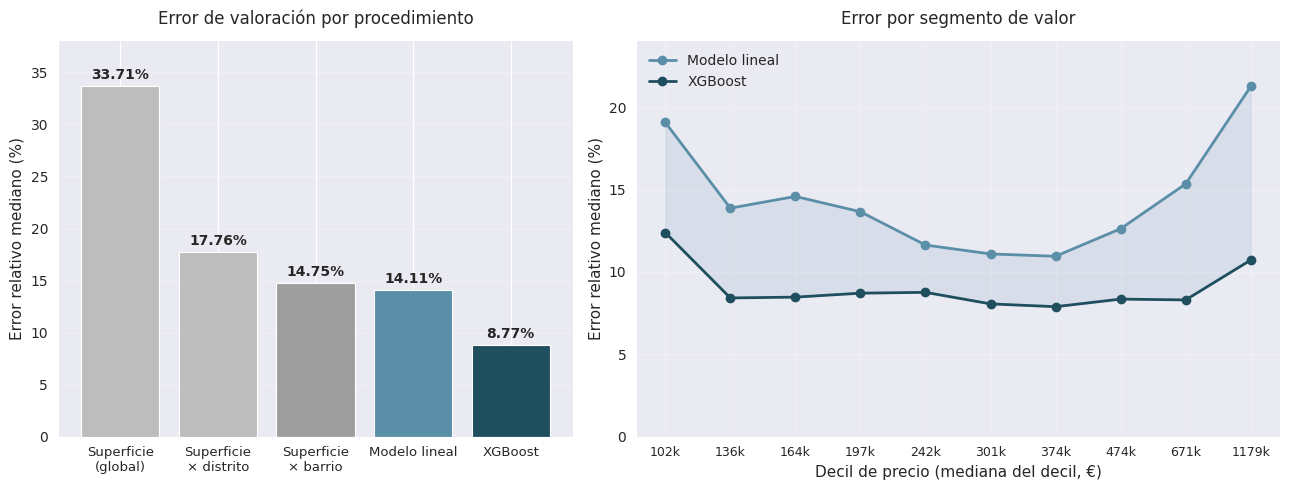

Figura guardada en figuras/06_comparativa_modelos.png


In [39]:
import matplotlib.pyplot as plt
Path("figuras").mkdir(exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                               gridspec_kw={"width_ratios": [1, 1.25]})

# --- Panel izquierdo: error por procedimiento --------------------------
orden = ["Ref. superficie (global)", "Ref. distrito (21)",
         "Ref. barrio (135)", "Modelo lineal (OLS)", "XGBoost"]
vals = [FINAL[k]["MdAPE (%)"] for k in orden]
etiq = ["Superficie\n(global)", "Superficie\n× distrito", "Superficie\n× barrio",
        "Modelo lineal", "XGBoost"]
colores = ["#BDBDBD", "#BDBDBD", "#9E9E9E", "#5B8FA8", "#1F4E5F"]

barras = ax1.bar(etiq, vals, color=colores, edgecolor="white", linewidth=0.8)
for b, v in zip(barras, vals):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.7, f"{v:.2f}%",
             ha="center", fontsize=10, fontweight="bold")

ax1.set_ylabel("Error relativo mediano (%)", fontsize=11)
ax1.set_title("Error de valoración por procedimiento", fontsize=12, pad=12)
ax1.set_ylim(0, 38)
ax1.tick_params(axis="x", labelsize=9.5)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", alpha=0.25, zorder=0)

# --- Panel derecho: error por decil de precio ----------------------------
x = por_decil.index
ax2.plot(x, por_decil["mdape_lineal"], "o-", color="#5B8FA8",
         lw=2, ms=6, label="Modelo lineal")
ax2.plot(x, por_decil["mdape_xgb"], "o-", color="#1F4E5F",
         lw=2, ms=6, label="XGBoost")
ax2.fill_between(x, por_decil["mdape_xgb"], por_decil["mdape_lineal"],
                 color="#5B8FA8", alpha=0.12)

ax2.set_xticks(x)
ax2.set_xticklabels([f"{p/1000:.0f}k" for p in por_decil["precio_mediano"]],
                    fontsize=9)
ax2.set_xlabel("Decil de precio (mediana del decil, €)", fontsize=11)
ax2.set_ylabel("Error relativo mediano (%)", fontsize=11)
ax2.set_title("Error por segmento de valor", fontsize=12, pad=12)
ax2.legend(frameon=False, fontsize=10)
ax2.set_ylim(0, 24)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("figuras/06_comparativa_modelos.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Figura guardada en figuras/06_comparativa_modelos.png")

### Síntesis del bloque

El modelo de alto rendimiento reduce el error del procedimiento de referencia en
un 40,5%, frente al 4,3% que alcanza el modelo interpretable. Sobre la vivienda
mediana del conjunto, la desviación esperada disminuye de 39.530 a 23.504 euros.
La diferencia entre ambos modelos no responde a la información disponible, que es
idéntica, sino a la capacidad de combinarla sin restricción aditiva.

La correspondencia entre las estimaciones obtenidas por validación cruzada y las
obtenidas sobre el conjunto reservado —14,04% frente a 14,11% en el modelo
interpretable, 8,97% frente a 8,77% en el de alto rendimiento— verifica que el
protocolo de validación no produjo estimaciones optimistas y que ninguno de los
dos modelos se ajustó al procedimiento de selección.

El modelo de alto rendimiento es asimismo el único de los cuatro procedimientos
cuyo coeficiente de dispersión se sitúa por debajo del valor de quince que el
estándar del sector considera admisible, y el único que elimina el sesgo
sistemático por tamaño presente tanto en la referencia como en el modelo
interpretable.

La proporción de valoraciones comprendidas dentro de un margen del diez por
ciento se mantiene entre el 55% y el 61% en los deciles segundo a noveno y
desciende al 42,8% y al 47,2% en los extremos de la distribución. El resultado
delimita el rango de valor en que la valoración automatizada resulta admisible
sin intervención profesional, situado de forma aproximada entre los 120.000 y los
900.000 euros, y sustenta en términos empíricos el uso declarado en el apartado
1.2 de la memoria.

# Bloque 9 — Guardado de los modelos (memoria 10)

El objeto serializado reúne ambos modelos con su preprocesado incorporado, de
modo que la aplicación reciba las características del inmueble en su formato
original y el pipeline resuelva internamente la imputación, la codificación y,
en el caso del modelo interpretable, la tramificación y el escalado. La
alternativa consistente en serializar únicamente el estimador obligaría a
replicar dicha lógica en la aplicación, con el consiguiente riesgo de
divergencia entre el tratamiento aplicado en entrenamiento y en explotación.

Se incorporan asimismo los metadatos necesarios para la explotación: el error
esperable de cada modelo, tanto agregado como por segmento de valor, requerido
para comunicar al usuario la fiabilidad de la valoración obtenida; los
coeficientes del modelo interpretable con sus etiquetas legibles, que sustentan
la explicación de la valoración; y la relación de variables de entrada con su
tipo, que permite validar las solicitudes recibidas.

El conjunto de validación se conserva por separado con las predicciones de ambos
modelos y los identificadores de zona, al constituir la base del análisis de
interpretabilidad y de equidad desarrollado en el notebook siguiente.

In [40]:
import joblib, json, sklearn
from pathlib import Path
Path("modelos").mkdir(exist_ok=True)

# --- Objeto para la aplicación ----------------------------------------
artefacto = {
    "modelos": {
        "lineal":  modelo_lineal,
        "xgboost": modelo_xgb,
    },
    "metricas": {n: FINAL[n].to_dict() for n in
                 ["Modelo lineal (OLS)", "XGBoost", "Ref. barrio (135)"]},
    "error_por_decil": por_decil.to_dict(),
    "coeficientes": coef[["Columna", "Etiqueta", "Coef",
                          "Efecto (%)", "p", "Bloque"]].to_dict("records"),
    "variables_entrada": {c: str(X_train[c].dtype) for c in X_train.columns},
    "hiperparametros_xgb": HIPERPARAMETROS_XGB,
    "etiquetas": ETIQUETAS_LEGIBLES,
    "metadatos": {
        "ambito": "Madrid, cuarto trimestre de 2018",
        "n_entrenamiento": int(len(X_train)),
        "n_validacion": int(len(X_test)),
        "objetivo": "log(PRICE); la valoración se obtiene por exponencial, "
                    "sin corrección de retro-transformación",
        "estimacion": "mediana condicional del precio",
        "semilla": int(SEMILLA),
        "versiones": {"sklearn": sklearn.__version__, "xgboost": xgb.__version__},
    },
}
joblib.dump(artefacto, "modelos/avm_madrid.joblib", compress=3)

# --- Conjunto de validación para el notebook de interpretabilidad -------
validacion = test[["LOCATIONID", "LOCATIONNAME", "DISTRITO",
                   "CONSTRUCTEDAREA", "PRICE", "geometry"]].copy()
validacion["pred_lineal"]  = np.exp(pred_test["Modelo lineal (OLS)"])
validacion["pred_xgboost"] = np.exp(pred_test["XGBoost"])
validacion["ratio_lineal"]  = validacion["pred_lineal"]  / validacion["PRICE"]
validacion["ratio_xgboost"] = validacion["pred_xgboost"] / validacion["PRICE"]
validacion.to_file("modelos/validacion_predicciones.gpkg", driver="GPKG")

# --- Verificación: el objeto recuperado reproduce las predicciones -------
a = joblib.load("modelos/avm_madrid.joblib")
for nombre, clave in [("Modelo lineal (OLS)", "lineal"), ("XGBoost", "xgboost")]:
    p = a["modelos"][clave].predict(X_test)
    assert np.allclose(p, pred_test[nombre]), f"{nombre} no reproduce"
print("Verificación superada: ambos modelos reproducen sus predicciones.\n")

tam = Path("modelos/avm_madrid.joblib").stat().st_size / 1e6
print(f"modelos/avm_madrid.joblib            {tam:.1f} MB")
print(f"modelos/validacion_predicciones.gpkg  {len(validacion):,} viviendas")
print(f"\nVersiones: scikit-learn {sklearn.__version__}, XGBoost {xgb.__version__}")

Verificación superada: ambos modelos reproducen sus predicciones.

modelos/avm_madrid.joblib            3.8 MB
modelos/validacion_predicciones.gpkg  6,284 viviendas

Versiones: scikit-learn 1.6.1, XGBoost 3.0.0
